![Nuclio logo](https://cdn.prod.website-files.com/633b44aa19e0eb425d7e8c7f/63724d646ecb4bd4cbdf7440_LOGO%20NUCLIO%20DIGITAL%20SCHOOL-01-01-p-500.png)

## 1. Librerias & Google Drive

Para empezar carguemos esas librerias que nos hacen falta

In [1]:
import tensorflow as tf
from tensorflow import keras as ks
from matplotlib import pyplot as plt
import numpy as np
import time
import datetime
import pickle
import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Importar las funciones de la carpeta src
import src.utils as utils
import src.utils_plots as plots
import src.cifar10_labels as cifar10
import src.utils_data_preparation as prepare

# rutas 
cifar10_labels = cifar10.cifar10_labels
data_dir = "cifar-10-batches-py/"
file_path = "models/final_"
 

Incorporamos la carpeta de Google Drive para poder "guardar" nuestros modelos

1. Abrir barra lateral de Carpeta
2.  Hacer click en carpeta con logo de Google Drive


In [40]:
# Aquí iria el codigo para conectarse a Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Proyecto 0

## 2. Arquitectura de red del modelo - Proyecto 0


In [41]:
model = ks.Sequential()

model.add(ks.layers.Input((32,32,3)))

model.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu',
                           padding='same'))
model.add(ks.layers.MaxPooling2D((2, 2)))

model.add(ks.layers.Flatten())
model.add(ks.layers.Dense(32, activation='relu'))
model.add(ks.layers.Dense(10, activation='softmax'))


Para revisar un modelo, nos basta con llamar al método **.summary()** del modelo

In [42]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,402 (1.00 MB)

 Trainable params: 263,402 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error


In [43]:
model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

Cargamos los datos de CIFAR10 de lo que os paso por Google Drive

https://drive.google.com/file/d/18uT-D7Ak2bj_SZ0nKdXLYDYuKVaaFfzJ/view?usp=sharing

Subid el archivo `cifar-10-batches-py.tar.gz` a vuestro Google Drive, a una carpeta conocida que luego tendréis que adaptar.

Luego pasaremos a cargarlos y post-procesarlos para tener un dataset idéntico al que tendrías cargado directamente de Keras

Nota: cambiad el PATH del comando `! cp` que apunte donde esté el `cifar-10-batches-py.tar.gz` localizado

In [44]:
# ! cp /content/drive/MyDrive/00_Nuclio_DS_Master/cifar-10-batches-py.tar.gz /content/
# ! tar -xzf /content/cifar-10-batches-py.tar.gz -C /content/

# ! ls -la /content
# ! ls -la /content/cifar-10-batches-py


In [45]:
data_dir = "cifar-10-batches-py/"

def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data_dir = "cifar-10-batches-py/"
def load_data(data_dir):
#load training data
 for i in range(1, 6):
  filename = data_dir+"data_batch_"+str(i)
  dictionary = unpickle(filename)
  x_data = dictionary[b'data']
  y_data = np.array(dictionary[b"labels"])
  if i==1:
   x_train = x_data
   y_train= y_data
  else:
   x_train = np.concatenate((x_train, x_data), axis = 0)
   y_train = np.concatenate((y_train, y_data), axis = 0)
#load testing data
 filename = data_dir+"test_batch"
 dictionary = unpickle(filename)
 x_test = dictionary[b"data"]
 y_test = np.array(dictionary[b"labels"])
 return x_train, y_train, x_test, y_test

def parse_record(record):
 depth_major = record.reshape((3, 32, 32))
 image = np.transpose(depth_major, [1, 2, 0])
 return image


In [46]:
# Si se pudiera cargar directamente de Keras, serian estas dos única líneas, pero es muy lenta la descarga
# cifar10 = ks.datasets.cifar10
# x_train, y_train, x_test, y_test = cifar10.load_data(data_dir)

x_train_rows, y_train, x_test_rows, y_test = load_data(data_dir)


In [47]:
x_train =  []
x_test =  []

for i in range(x_train_rows.shape[0]):
  x_train.append(parse_record(x_train_rows[i]))

for i in range(x_test_rows.shape[0]):
  x_test.append(parse_record(x_test_rows[i]))

x_train = np.array(x_train)
x_test = np.array(x_test)

In [48]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [49]:
x_train_scaled, x_test_scaled = x_train / 255.0, x_test / 255.0

In [50]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


Obtenemos un array con todas las labels de CIFAR10

In [51]:
cifar10_labels = [
'airplane', # id 0
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck'
]

print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Pintemos una muestra de las imagenes del dataset CIFAR10, a ver si se parece en algo a lo que esperamos.
Primero, vemos que tipos de datos tengo, después mapeamos esas matrices en una escala de grises utilizando el método **.get_cmap()** de PlotLy con los nueve primeros números del dataset.

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


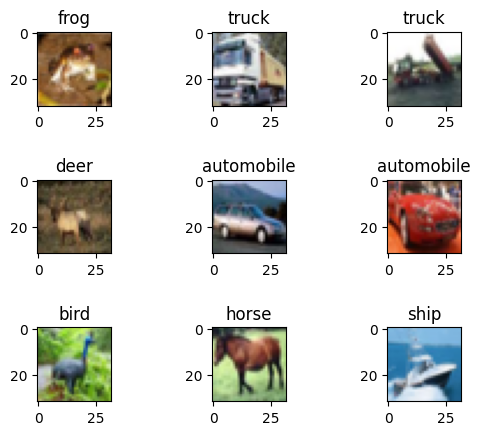

In [52]:
# Pintemos una muestra de las las imagenes del dataset MNIST

print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

for i in range(9):

    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
    plt.title(cifar10_labels[y_train[i]])

plt.subplots_adjust(hspace = 1)
plt.show()

Como vamos a querer ir haciendo validación a la vez que entrenamos (muy practico)

In [53]:
x_val_scaled = x_train_scaled[-10000:]
y_val = y_train[-10000:]

x_train_scaled = x_train_scaled[:-10000]
y_train = y_train[:-10000]


Cuando añadimos convoluciones, necesitamos "pre-tratar los datos", porque **la convolución espera una matriz de 4 campos** (más parecido a "imagenes"), en el caso de MNIST. CIFAR10 ya tiene el shape adecuado, así que no tenemos que hacer nada, pero como siempre decimos: es mejor que comprobeis su tamaño.

Por eso, al salir de la Convolution, hay que hacer un Flatten, porque las capas FullDense esperan arrays, no matrices!!

Luego lo imprimimos para ver que todo está correcto

In [54]:
# Validamos el resultado
print('Train: X=%s, y=%s' % (x_train_scaled.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test_scaled.shape, y_test.shape))
print('Validation: X=%s, y=%s' % (x_val_scaled.shape, y_val.shape))

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

Ya podemos ponernos a entrenar el modelo!! Ojo, que hemos de entrenar contra los datos convertidos al formato que espera la Convolution.

Empezaremos con 30 epocs, es decir, 30 pasadas completas del dataset (que a su vez sera con mini-batches internamente), fijando un batch de 64

El metodo .fit() nos permite, definir además si disponemos de varias CPUs, GPUs, y si queremos ir validando datos a cada fin de epoch.

In [55]:
t = time.perf_counter()

history = model.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2965 - loss: 1.9503 - val_accuracy: 0.4019 - val_loss: 1.7529
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4219 - loss: 1.6590 - val_accuracy: 0.4480 - val_loss: 1.5896
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4712 - loss: 1.5195 - val_accuracy: 0.4538 - val_loss: 1.5359
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.5077 - loss: 1.4221 - val_accuracy: 0.5066 - val_loss: 1.4230
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5313 - loss: 1.3504 - val_accuracy: 0.5414 - val_loss: 1.3472
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5515 - loss: 1.2940 - val_accuracy: 0.5334 - val_loss: 1.3551
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5625 - loss: 1.2573 - val_accuracy: 0.5494 - val_loss: 1.2983
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5765 - loss: 1.2195 - val_accuracy: 0.5575 - v

In [56]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:01:06.991023


## 6. Evaluamos los resultados

Obtengamos una grafica de como el error y la accuracy van evolucionando en cada epoch en los datos de entrenamiento y en la validación

In [57]:
_, acc = model.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 59.230


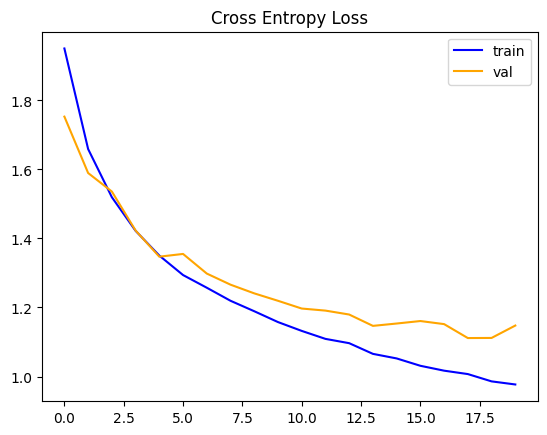

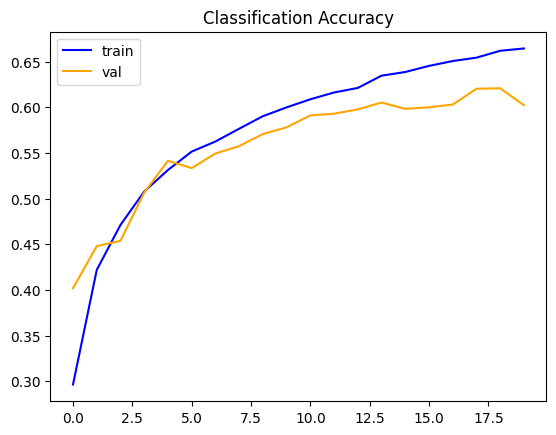

In [58]:
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='val')
plt.legend()
plt.show()

plt.title('Classification Accuracy')
plt.plot(history.history['accuracy'], color='blue', label='train')
plt.plot(history.history['val_accuracy'], color='orange', label='val')
plt.legend()
plt.show()

El coste podemos ver que es estable y es en el epoch 15 que se fija en un valor. Además la accuracy baila alrededor de 0.10. No se puede decir que sea un modelo muy bueno.

Veamos que tipo de predicciones estoy obteniendo sobre el conjunto de test (vamos a pintar las imagenes y sus clasificaciones)

In [59]:
predictions = model.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Una de las ventajas de Python es que hay montones de funciones y código realizado por terceras personas. Aquí me he fusilado unas bonitas funciones (que he adaptado un poco a mis necesidades) para poder pintar las imagenes, su label (ground truth) y las clasificaciones que hemos realizado.

Dibujamos las primeras imagenes, con las predicciones y sus valores reales (un total de 20 imagenes, para no abusar de vuestros laptops)

Coloreamos las prediciones correctas en azul y los fallos en rojo. Aunque primero he impreso las etiquetas para que tengamos una referencia al grafico.

In [60]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


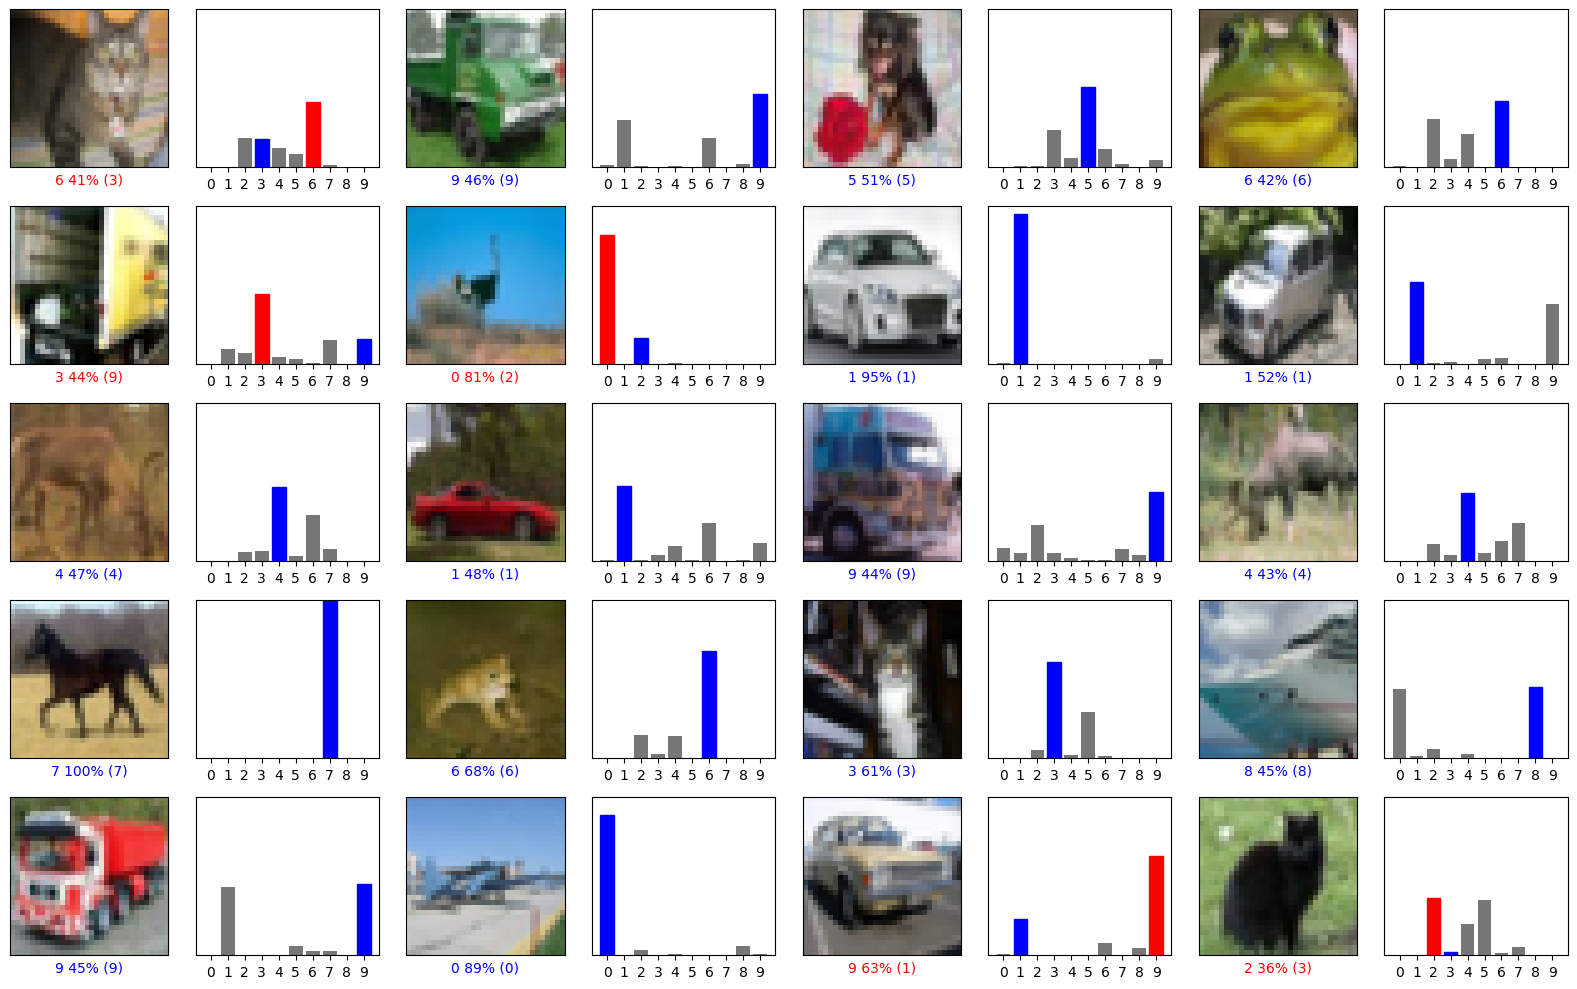

In [61]:
i = 0
for l in cifar10_labels:
    print(i, l)
    i += 1

num_rows = 5
num_cols = 4
start = 650
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i+start, predictions[i+start], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i+start, predictions[i+start], y_test)
plt.tight_layout()
plt.show()

## 7. Guardamos el modelo para futuras evaluaciones

Id cambiando los nombres del archivo para ir guardando los diversos proyectos.
Aquí lo guardamos en "local", pero recordad que lo ideal es que lo guardeis en Google Drive (teneis que montar la unidad, fijar la ruta y allí guardar el modelo .h5)

In [96]:
# ruta_googledrive = "/content/drive/MyDrive/" # A revisar en vuestra instancia
# model.save(ruta_googledrive+'cifar10_base_model.keras')

model.save(file_path +'cifar10_base_model.keras')

# Proyecto 1 - Cambio a Layers/Capas

### Hipotesis:
Añadir otra capa/layer para usar lo que vimos en el proyecto 0 va aumentar el rendimiento.

## 2. Arquitectura de red del modelo - Proyecto 1


Vamos añadir otro capa/layer para usar lo que aprendimos en la primera capa. 

In [63]:
model_1 = ks.Sequential()
model_1.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_1.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_1.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_1.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_1.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_1.add(ks.layers.MaxPooling2D((2, 2)))

model_1.add(ks.layers.Flatten())
model_1.add(ks.layers.Dense(32, activation='relu'))
model_1.add(ks.layers.Dense(10, activation='softmax'))


In [64]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,290 (333.16 KB)

 Trainable params: 85,290 (333.16 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error

In [65]:
model_1.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

### Cargar dataset de nuevo

In [66]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


### Escalar datos

In [67]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [68]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


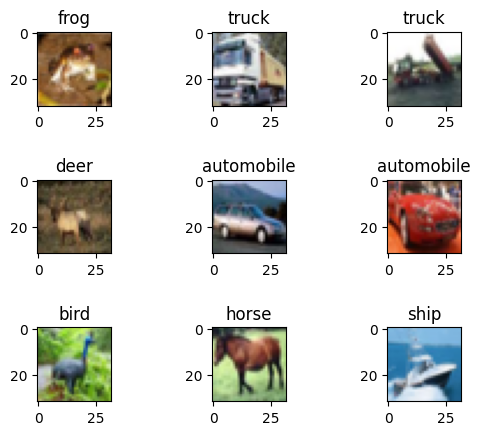

In [69]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

### Crear datos de validación 

In [ ]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [71]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [72]:
t = time.perf_counter()

history = model_1.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.3304 - loss: 1.8541 - val_accuracy: 0.4378 - val_loss: 1.5723
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.4591 - loss: 1.5099 - val_accuracy: 0.4705 - val_loss: 1.4990
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5101 - loss: 1.3811 - val_accuracy: 0.5201 - val_loss: 1.3493
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.5428 - loss: 1.2970 - val_accuracy: 0.5503 - val_loss: 1.2798
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5672 - loss: 1.2290 - val_accuracy: 0.5977 - val_loss: 1.1701
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.5892 - loss: 1.1705 - val_accuracy: 0.6027 - val_loss: 1.1372
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.6073 - loss: 1.1235 - val_accuracy: 0.6256 - val_loss: 1.0855
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6214 - loss: 1.0816 - val_accuracy: 0.6346 -

## 6. Evaluamos los resultados

Hemos podido mejorar el accuracy por 10 puntos usando otra capa.

In [73]:
_, acc = model_1.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 67.970


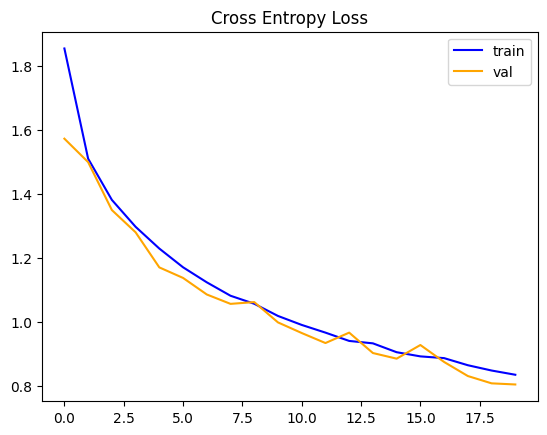

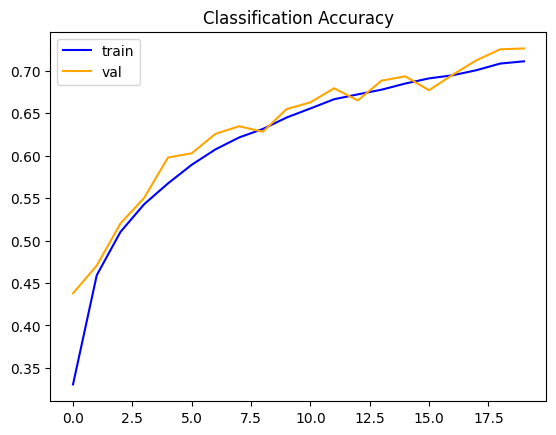

In [74]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

In [75]:
predictions = model_1.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


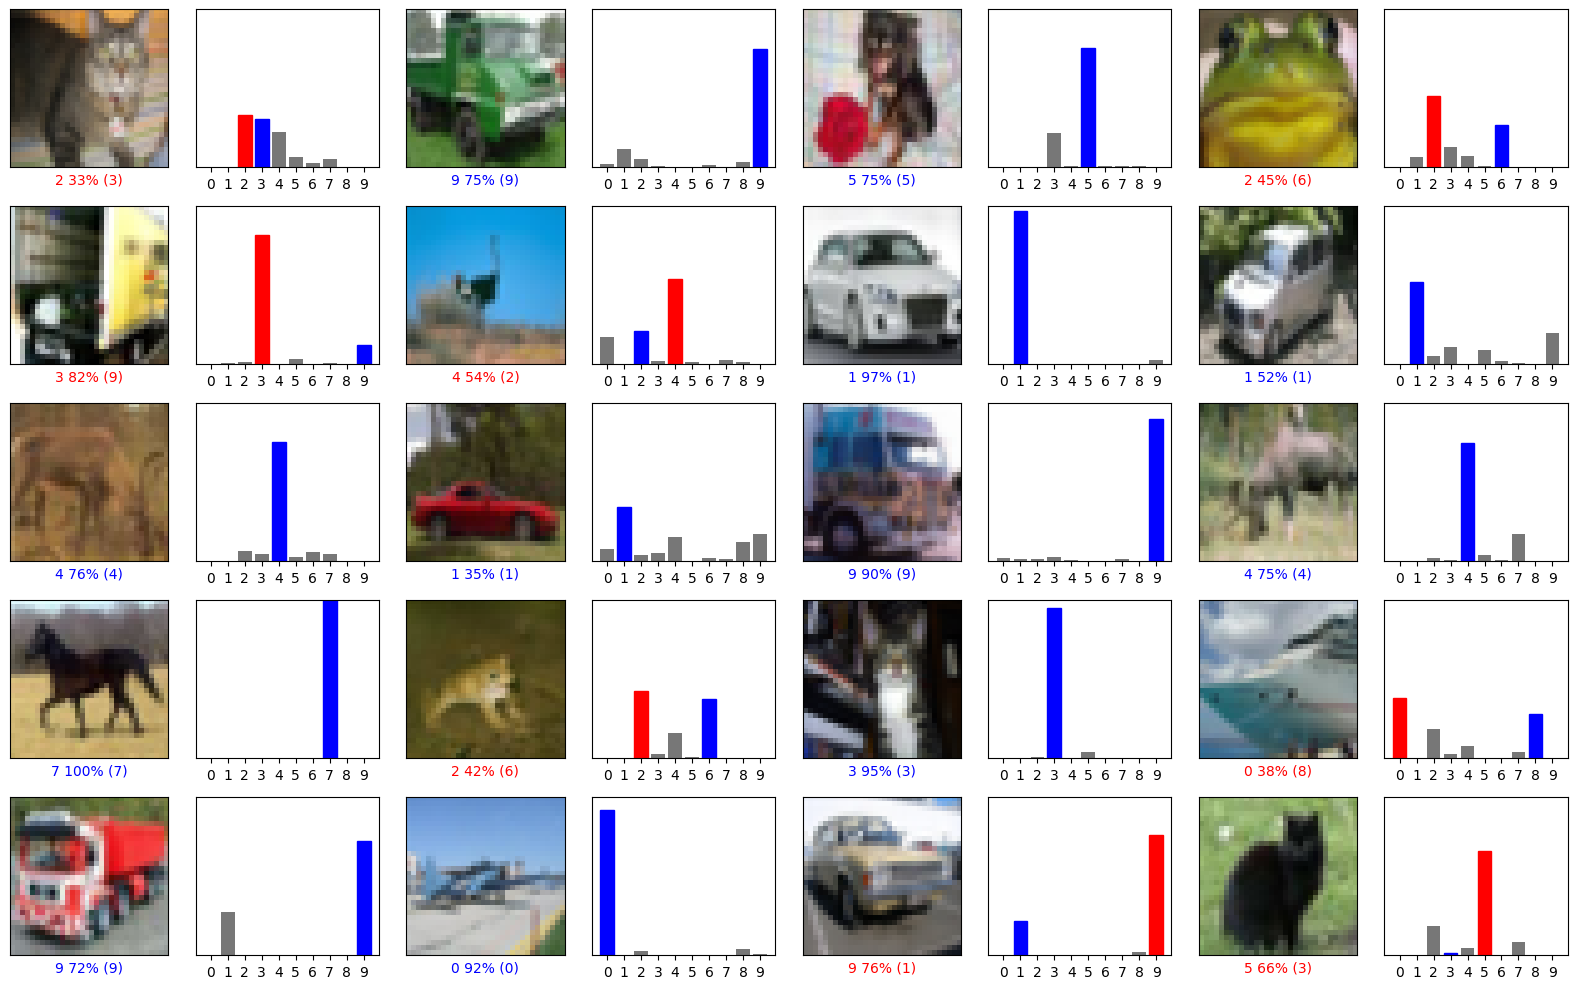

In [76]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

El modelo acierta el gato, que no pudo acertar en el Proyecto 0.

## 7. Guardamos el modelo para futuras evaluaciones

In [97]:
# ruta_googledrive = "/content/drive/MyDrive/" # A revisar en vuestra instancia
# model.save(ruta_googledrive+'cifar10_base_model.keras')

# file_path = "models/"

model_1.save(file_path +'cifar10_model_1.keras')

# Proyecto 2 

### Hipotesis: 
Añadir otra capa encima de las dos que hemos puesto en el proyecto 1 va mejorar el rendimiento porque mientras comprimiemos el imagen, los patrones que ha aprendido puede ayudar clasificar mejor.

## 2. Arquitectura de red del modelo - Proyecto 2


In [78]:
model_2 = ks.Sequential()
model_2.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_2.add(ks.layers.MaxPooling2D((2, 2)))

model_2.add(ks.layers.Flatten())
model_2.add(ks.layers.Dense(32, activation='relu'))
model_2.add(ks.layers.Dense(10, activation='softmax'))


In [79]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,634 (213.41 KB)

 Trainable params: 54,634 (213.41 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error

In [80]:
model_2.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

### Cargar dataset de nuevo

In [81]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [82]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


### Escalar datos

In [83]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [84]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


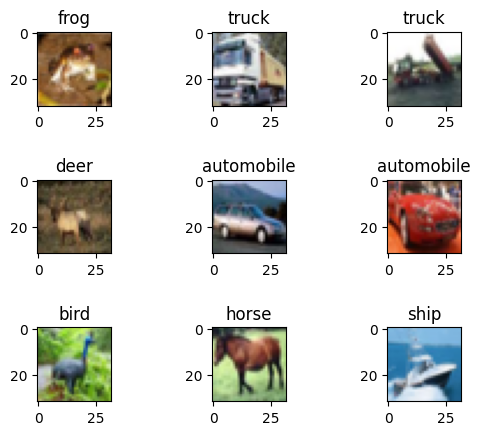

In [85]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

### Crear datos de validación

In [86]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [87]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [88]:
t = time.perf_counter()

history = model_2.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.2890 - loss: 1.9550 - val_accuracy: 0.3497 - val_loss: 1.7915
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.4188 - loss: 1.6102 - val_accuracy: 0.4505 - val_loss: 1.5412
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.4676 - loss: 1.4780 - val_accuracy: 0.4938 - val_loss: 1.4154
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.5056 - loss: 1.3766 - val_accuracy: 0.4776 - val_loss: 1.4779
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.5304 - loss: 1.3142 - val_accuracy: 0.5477 - val_loss: 1.2906
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.5573 - loss: 1.2474 - val_accuracy: 0.5505 - val_loss: 1.2682
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.5757 - loss: 1.1984 - val_accuracy: 0.5707 - val_loss: 1.2185
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.5907 - loss: 1.1604 - val_accuracy: 0.5490 -

In [89]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:02:39.762155


## 6. Evaluamos los resultados

In [90]:
_, acc = model_2.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 64.030


Ha empeorado con otra capa, sugeriendo que no aportó mucho esta nueva capa. Tal vez hay que aumentar el número de epochs o hacer otros cambios.

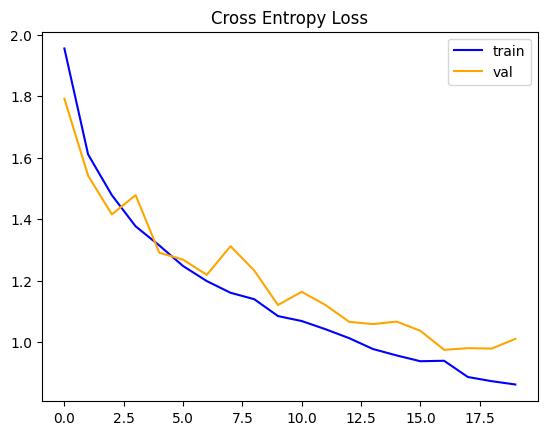

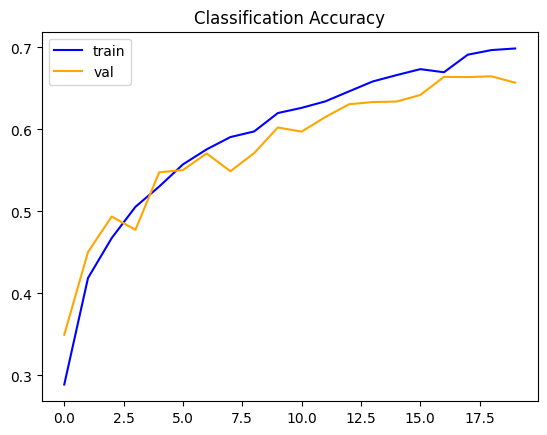

In [91]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

In [92]:
predictions = model_2.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


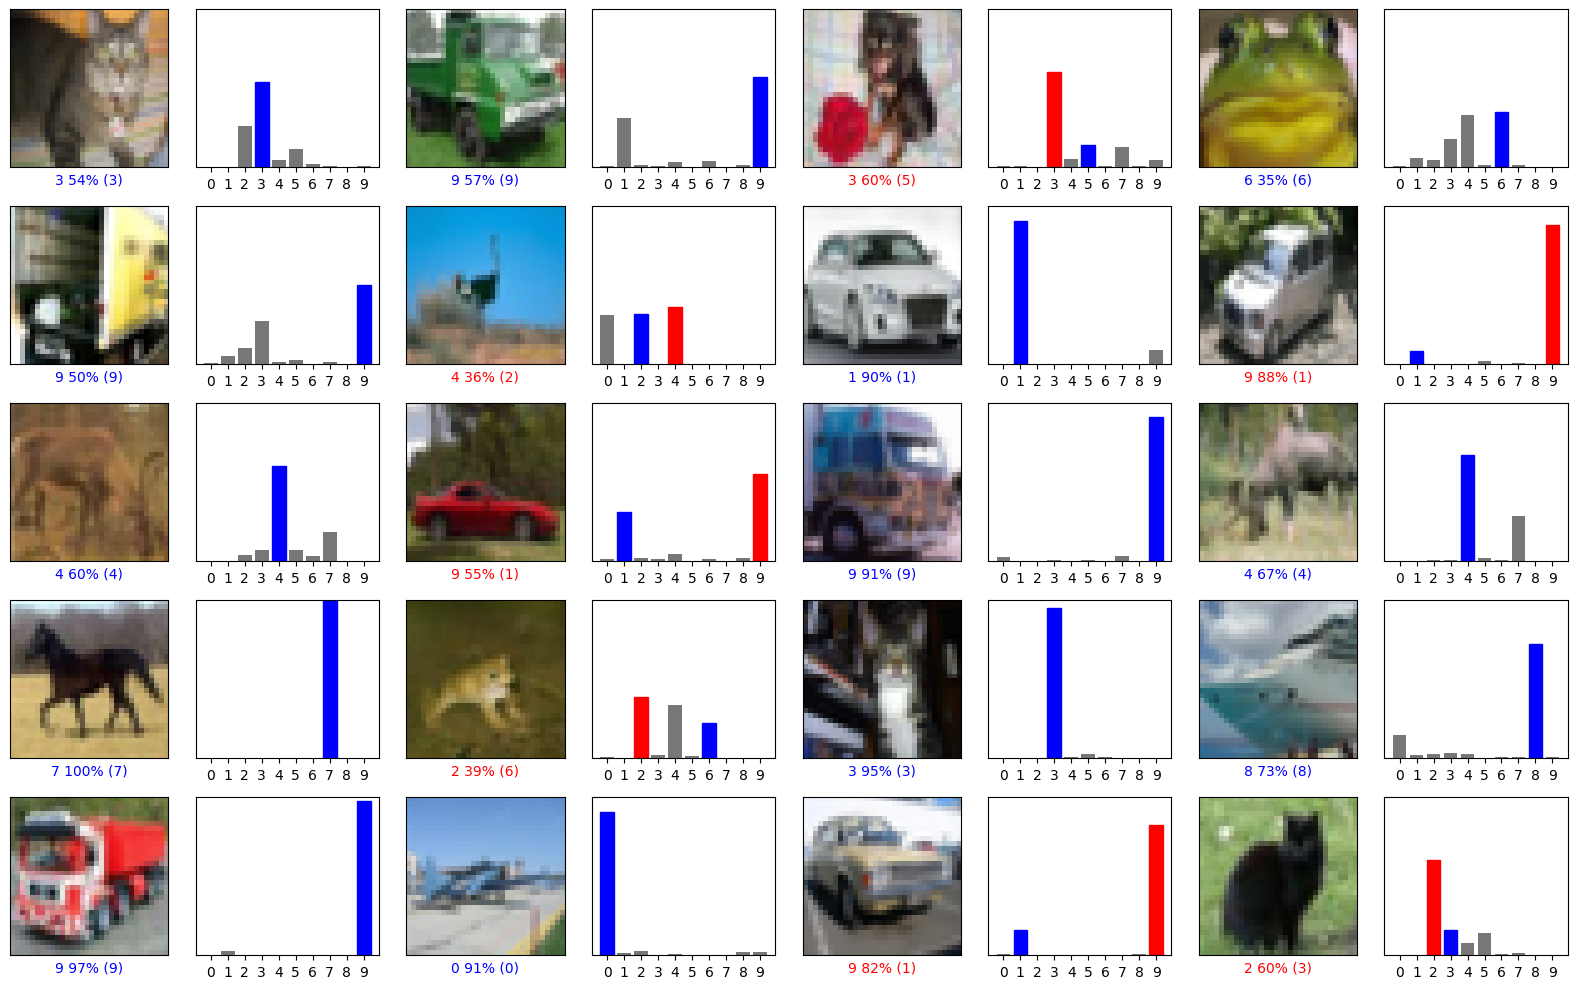

In [93]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

Sigue equivocandose en las mismas del Proyecto 1

## 7. Guardamos el modelo para futuras evaluaciones

In [98]:
model_2.save(file_path +'cifar10_model_2.keras')

# Proyecto 3 

### Hipotesis: 
Aumentando los epochs va mejorar el rendimiento del modelo usando la misma arquitectura del proyecto 2. Vamos a cambiar el número de filtros en una de las capas.

## 2. Arquitectura de red del modelo - Proyecto 3


In [ ]:
model_3 = ks.Sequential()
model_3.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa con más filtros.
model_3.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_3.add(ks.layers.MaxPooling2D((2, 2)))

model_3.add(ks.layers.Flatten())
model_3.add(ks.layers.Dense(32, activation='relu'))
model_3.add(ks.layers.Dense(10, activation='softmax'))


In [100]:
model_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,634 (213.41 KB)

 Trainable params: 54,634 (213.41 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error

In [101]:
model_3.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

### Cargar dataset de nuevo

In [2]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [3]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


### Escalar datos

In [4]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [5]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


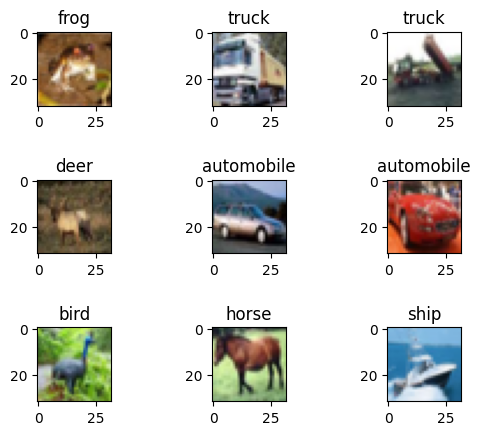

In [6]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

### Crear datos de validación

In [11]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [12]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(20000, 32, 32, 3), y=(20000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

### Cambios en el entrenamiento

Vamos a probar con más epochs.

In [108]:
t = time.perf_counter()

history = model_3.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.2600 - loss: 2.0204 - val_accuracy: 0.3613 - val_loss: 1.7983
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.4085 - loss: 1.6422 - val_accuracy: 0.4282 - val_loss: 1.5672
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.4601 - loss: 1.4841 - val_accuracy: 0.4891 - val_loss: 1.4244
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.5004 - loss: 1.3878 - val_accuracy: 0.5155 - val_loss: 1.3598
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.5240 - loss: 1.3265 - val_accuracy: 0.4923 - val_loss: 1.4202
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.5482 - loss: 1.2633 - val_accuracy: 0.5614 - val_loss: 1.2343
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.5733 - loss: 1.2033 - val_accuracy: 0.5527 - val_loss: 1.2603
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.5861 - loss: 1.1597 - val_accuracy: 0

In [109]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:04:12.341545


## 6. Evaluamos los resultados

In [110]:
_, acc = model_3.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 65.910


Ha subido el accuracy con más epochs y capas. 

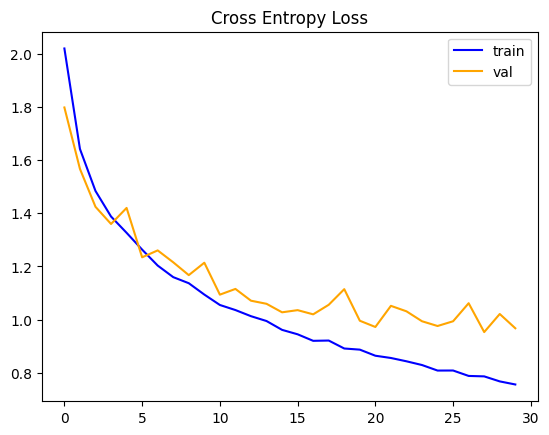

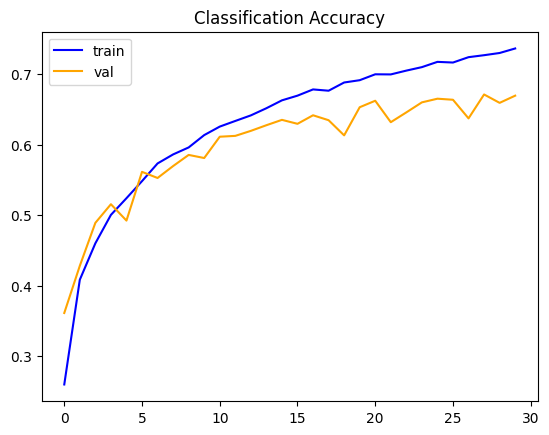

In [111]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

Parece que se estabilisa después de 25 epochs. Con más epochs, podría ir mejorando o tal vez correr riesgo de overfitting.

In [112]:
predictions = model_3.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


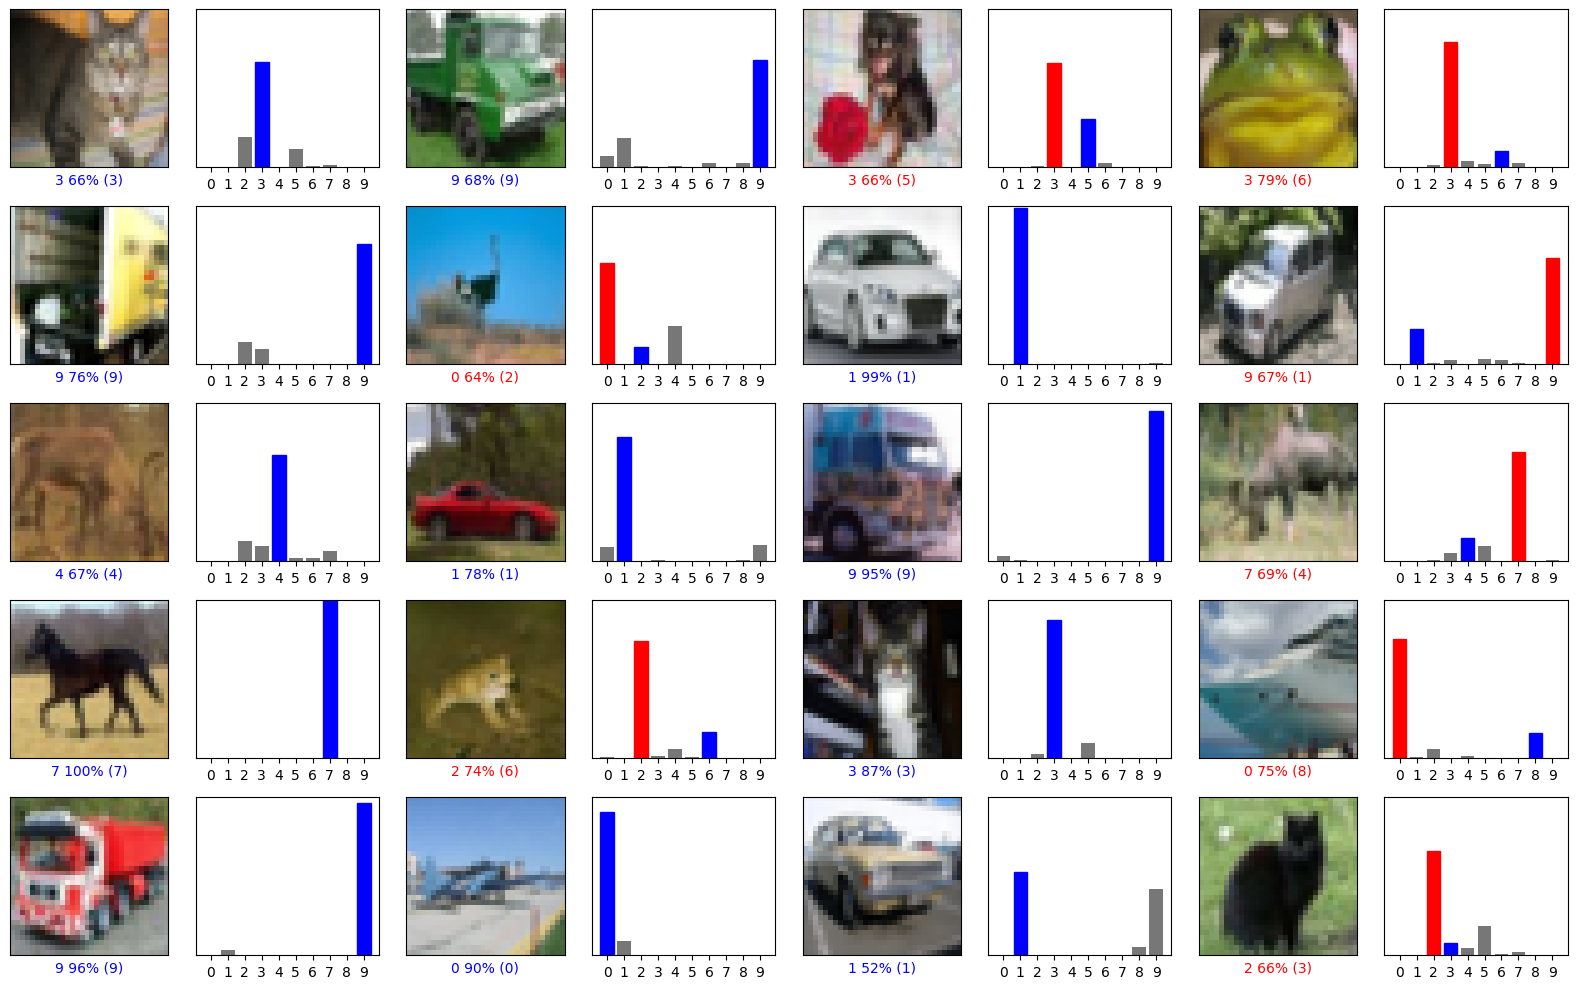

In [113]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

Parece que autos todavía causan una mica de problemas.

## 7. Guardamos el modelo para futuras evaluaciones

In [114]:
model_3.save(file_path +'cifar10_model_3.keras')

# Proyecto 4 - Cambio a Capa/Inputs

### Hipotesis:
En vez de seguir comprimiendo la imagen, vamos a volver a crear una capa de 64 canales para aumentar el número de parametros. Esto va ayudar nuestro modelo clasificar mejor. También vamos a aumentar la densidad para que no perdamos mucha información.

## 2. Arquitectura de red del modelo - Proyecto 4


In [23]:
model_4 = ks.Sequential()
model_4.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

# Cambio de 32 -> 64 que tuvimos en el Proyecto 3
model_4.add(ks.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_4.add(ks.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_4.add(ks.layers.MaxPooling2D((2, 2)))

model_4.add(ks.layers.Flatten())

# Aumentando densidad para evitar perder mucha información
model_4.add(ks.layers.Dense(128, activation='relu'))
model_4.add(ks.layers.Dense(10, activation='softmax'))


In [24]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,498 (498.04 KB)

 Trainable params: 127,498 (498.04 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error

In [25]:
model_4.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

In [17]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [18]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [19]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [20]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


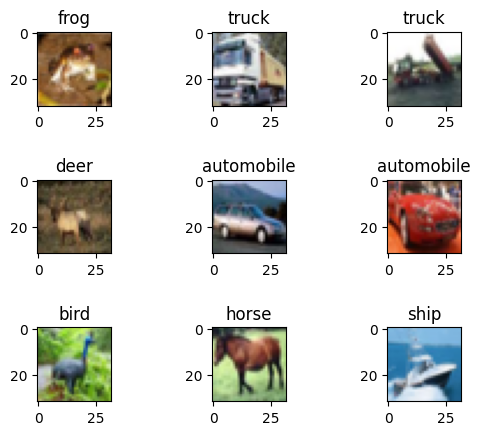

In [12]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [21]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [22]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [26]:
t = time.perf_counter()

history = model_4.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.2685 - loss: 1.9852 - val_accuracy: 0.3753 - val_loss: 1.7031
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.4146 - loss: 1.5918 - val_accuracy: 0.3829 - val_loss: 1.7229
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.4724 - loss: 1.4425 - val_accuracy: 0.4859 - val_loss: 1.4309
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.5241 - loss: 1.3120 - val_accuracy: 0.4791 - val_loss: 1.4907
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.5534 - loss: 1.2397 - val_accuracy: 0.5467 - val_loss: 1.2585
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.5781 - loss: 1.1751 - val_accuracy: 0.5692 - val_loss: 1.1827
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.6035 - loss: 1.1162 - val_accuracy: 0.5939 - val_loss: 1.1396
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.6234 - loss: 1.0578 - val_accurac

In [27]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:04:40.457790


## 6. Evaluamos los resultados

In [28]:
_, acc = model_4.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 66.560


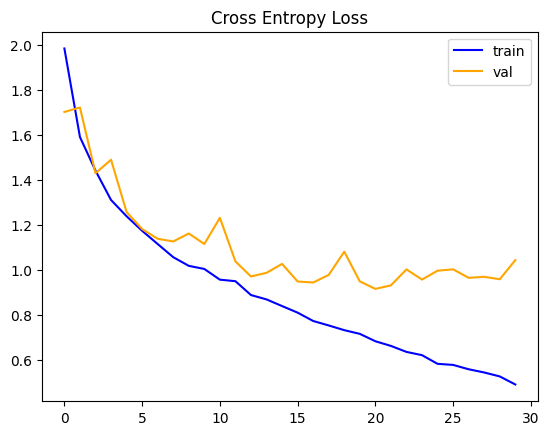

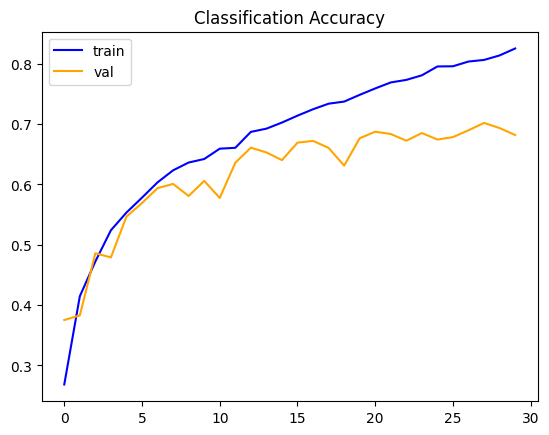

In [29]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

Parece que hay overfitting cuando se entrena, y el mismo rendimiento no se refleja cuando valida.

In [30]:
predictions = model_4.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


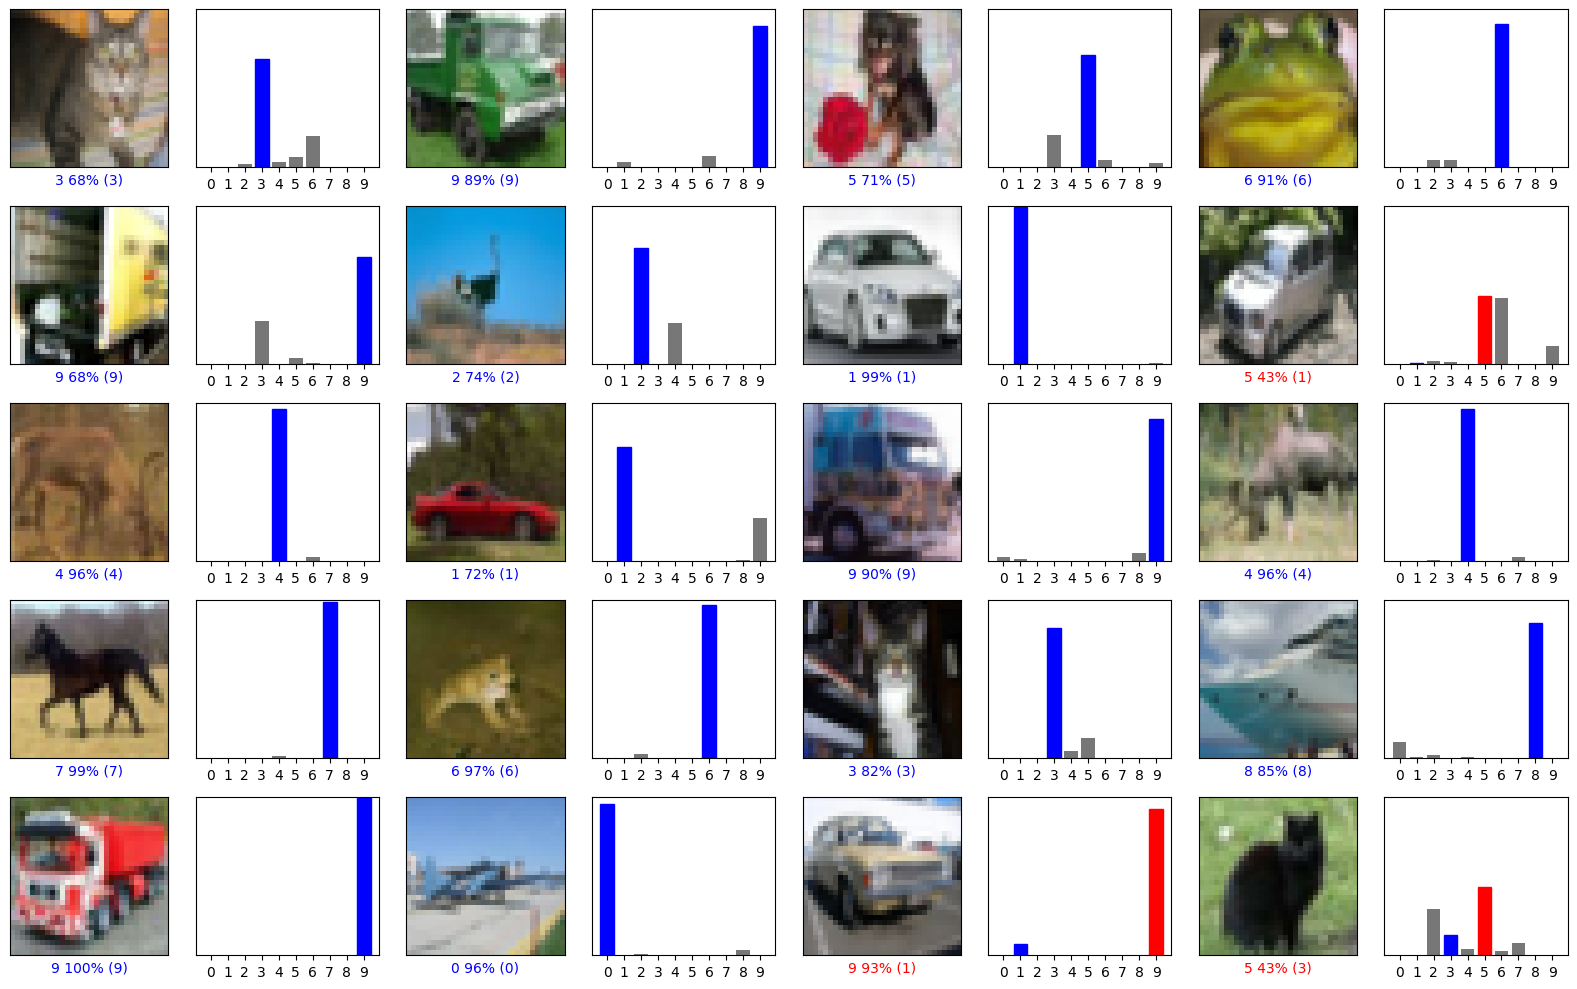

In [31]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

Vemos que sabe los imagenes super bien, pero todavía falla.

## 7. Guardamos el modelo para futuras evaluaciones

In [32]:
model_4.save(file_path +'cifar10_model_4.keras')

# Proyecto 5 - Cambio a Capa/Inputs

### Hipotesis:
Vimos una tendencia de overfitting en el proyecto 4. Vamos a tratar de incorporar regularización para prevenir eso pero también para mejorarlo.

## 2. Arquitectura de red del modelo - Proyecto 5


In [3]:
model_5 = ks.Sequential()
model_5.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.BatchNormalization())
model_5.add(ks.layers.MaxPooling2D((2, 2)))
model_5.add(ks.layers.Dropout(0.25))

# Nueva capa
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.BatchNormalization())
model_5.add(ks.layers.MaxPooling2D((2, 2)))
model_5.add(ks.layers.Dropout(0.25)) 

# Otra capa encima de esa
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_5.add(ks.layers.BatchNormalization())
model_5.add(ks.layers.MaxPooling2D((2, 2)))
model_5.add(ks.layers.Dropout(0.25)) 

model_5.add(ks.layers.Flatten())
model_5.add(ks.layers.Dense(128, activation='relu'))
model_5.add(ks.layers.Dropout(0.5))
model_5.add(ks.layers.Dense(10, activation='softmax'))

## 3. Optimizador, función error

In [4]:
model_5.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

In [5]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [6]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [7]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


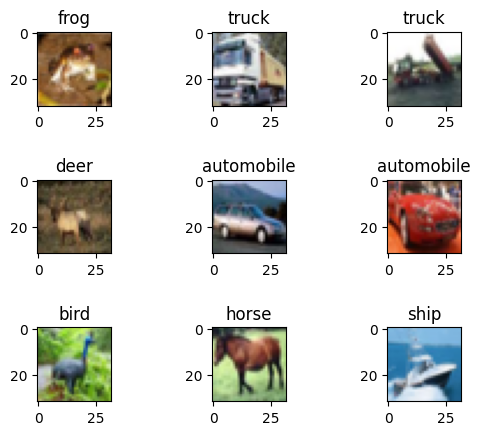

In [8]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [9]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [10]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [11]:
t = time.perf_counter()

# Volvemos a 20 epochs
history = model_5.fit(x_train_scaled, y_train, epochs=20,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.2195 - loss: 2.2388 - val_accuracy: 0.0997 - val_loss: 4.3307
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.3449 - loss: 1.7737 - val_accuracy: 0.0997 - val_loss: 6.3661
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.4137 - loss: 1.5944 - val_accuracy: 0.0997 - val_loss: 5.8085
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.4534 - loss: 1.4971 - val_accuracy: 0.1449 - val_loss: 3.7036
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.4843 - loss: 1.4126 - val_accuracy: 0.2004 - val_loss: 3.4356
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.5117 - loss: 1.3526 - val_accuracy: 0.3403 - val_loss: 2.1068
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.5290 - loss: 1.2995 - val_accuracy: 0.4273 - val_loss: 1.8070
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.5541 - loss: 1.2391 - val_accu

In [12]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:05:01.699843


## 6. Evaluamos los resultados

In [13]:
_, acc = model_5.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 71.040


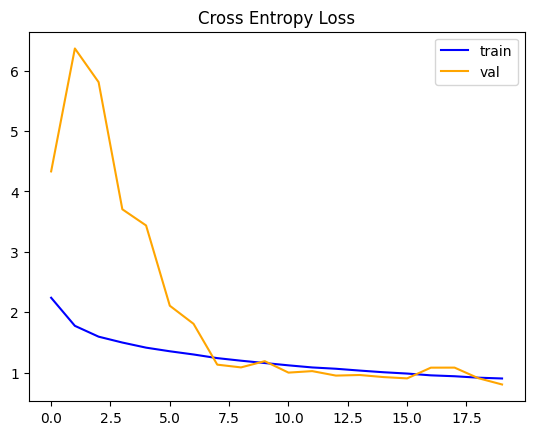

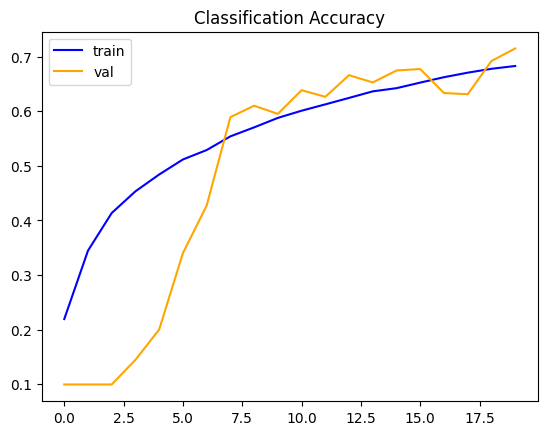

In [14]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

Hay un cambio de como aprende. Aprende rápidamente después de algunos epochs.

In [15]:
predictions = model_5.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


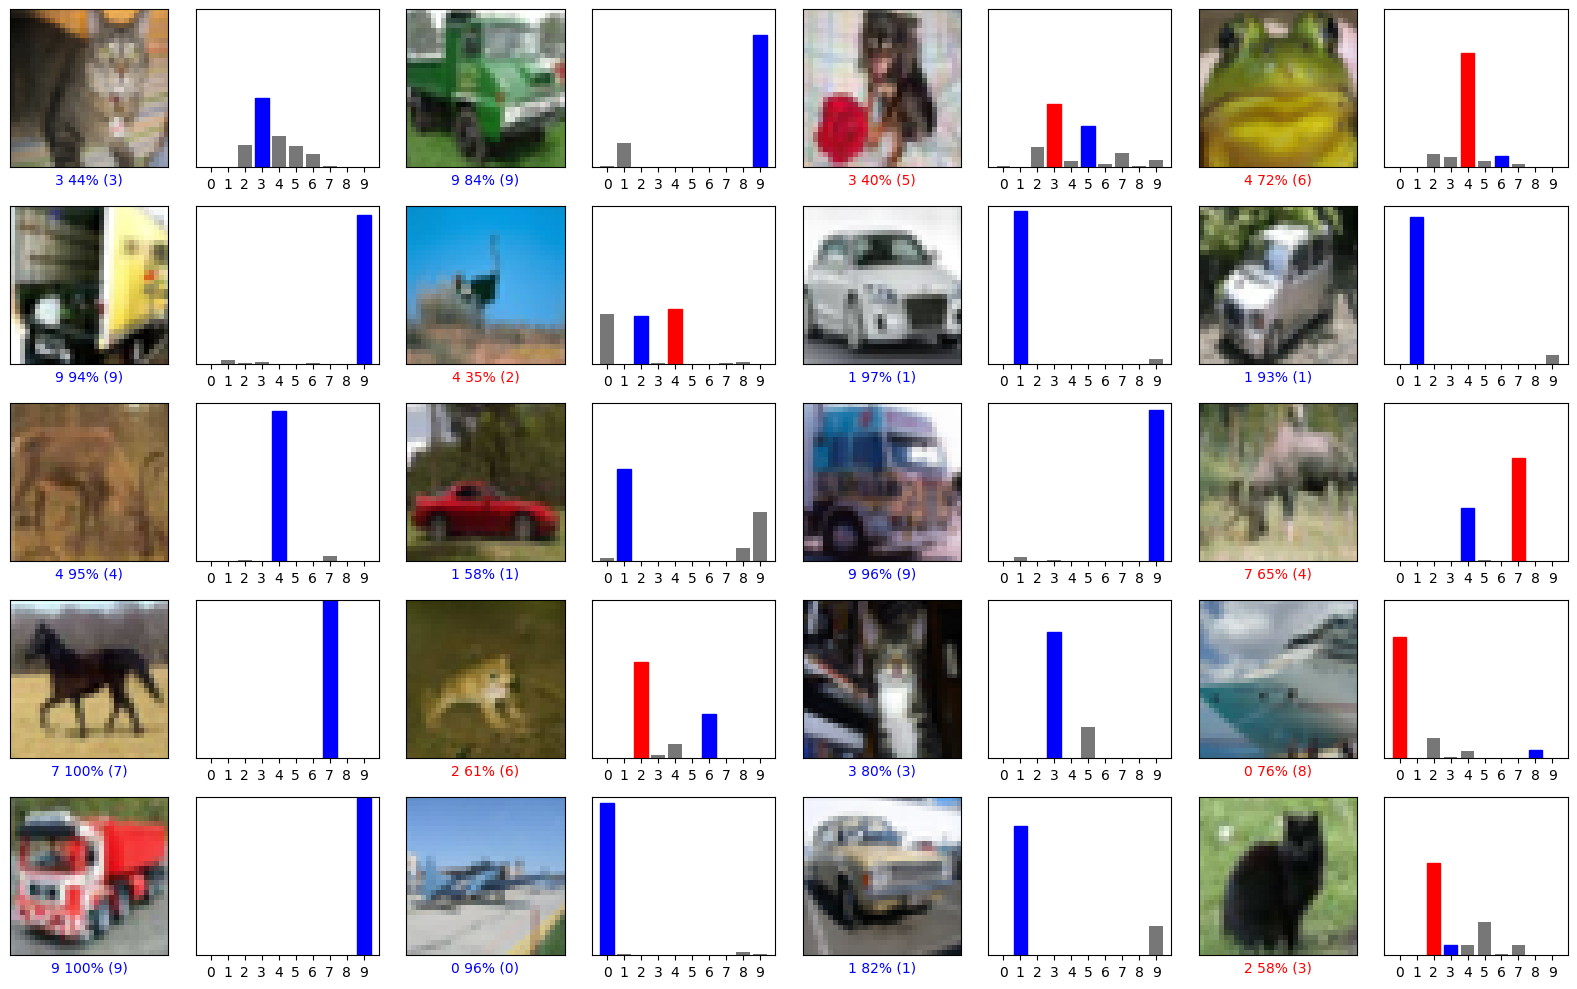

In [16]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

## 7. Guardamos el modelo para futuras evaluaciones

In [17]:
model_5.save(file_path +'cifar10_model_5.keras')

<!-- Dropout  -->

# Proyecto 6 - Cambio a Capa/Inputs

### Hipotesis:
Aumentando los filtros sucesivamente va mejorar el rendimiento del modelo. Quitar la regularización y dejar que los filtros aprendan mejor.

## 2. Arquitectura de red del modelo - Proyecto 6

In [2]:
model_6 = ks.Sequential()
model_6.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_6.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_6.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.MaxPooling2D((2, 2)))

# Otra capa encima de esa
model_6.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_6.add(ks.layers.MaxPooling2D((2, 2)))

model_6.add(ks.layers.Flatten())
model_6.add(ks.layers.Dense(128, activation='relu'))
model_6.add(ks.layers.Dense(10, activation='softmax'))


In [3]:
model_6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,322 (2.06 MB)

 Trainable params: 541,322 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error

In [4]:
model_6.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

In [5]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [6]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [7]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [29]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


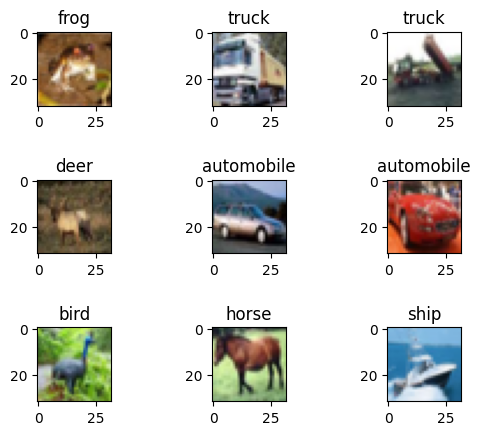

In [8]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [9]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [10]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [11]:
t = time.perf_counter()

history = model_6.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.3126 - loss: 1.8781 - val_accuracy: 0.4197 - val_loss: 1.5749
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 304ms/step - accuracy: 0.4779 - loss: 1.4332 - val_accuracy: 0.5114 - val_loss: 1.3616
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 288ms/step - accuracy: 0.5410 - loss: 1.2686 - val_accuracy: 0.5511 - val_loss: 1.2655
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.5910 - loss: 1.1455 - val_accuracy: 0.5938 - val_loss: 1.1574
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step - accuracy: 0.6262 - loss: 1.0587 - val_accuracy: 0.6311 - val_loss: 1.0425
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 314ms/step - accuracy: 0.6676 - loss: 0.9485 - val_accuracy: 0.6632 - val_loss: 0.9622
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 275ms/step - accuracy: 0.6970 - loss: 0.8684 - val_accuracy: 0.6771 - val_loss: 0.9088
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - accuracy: 0.7123 - loss: 0.8190 - val_accu

In [12]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:32:04.003163


## 6. Evaluamos los resultados

In [13]:
_, acc = model_6.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 73.040


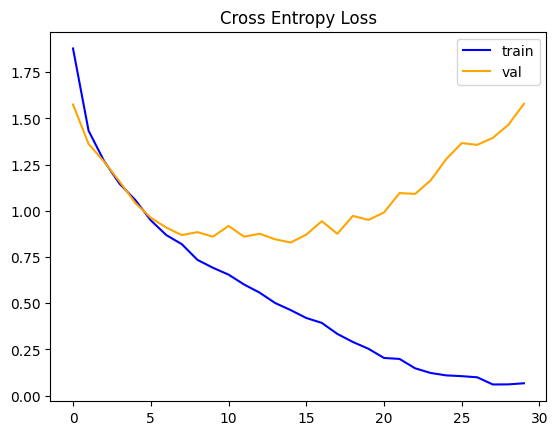

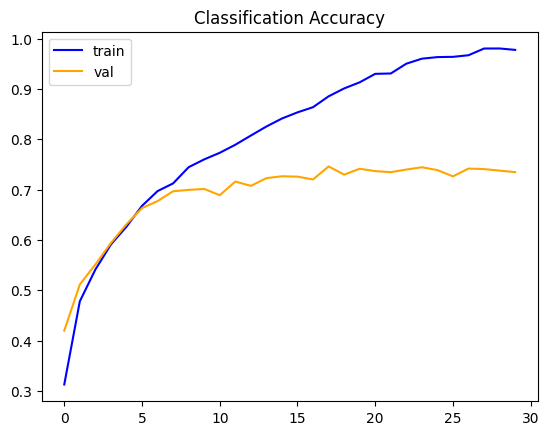

In [14]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

Ha mejorado el modelo. Podemos hacer otra ronda de regularización, y después augmentación de datos. 

In [15]:
predictions = model_6.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


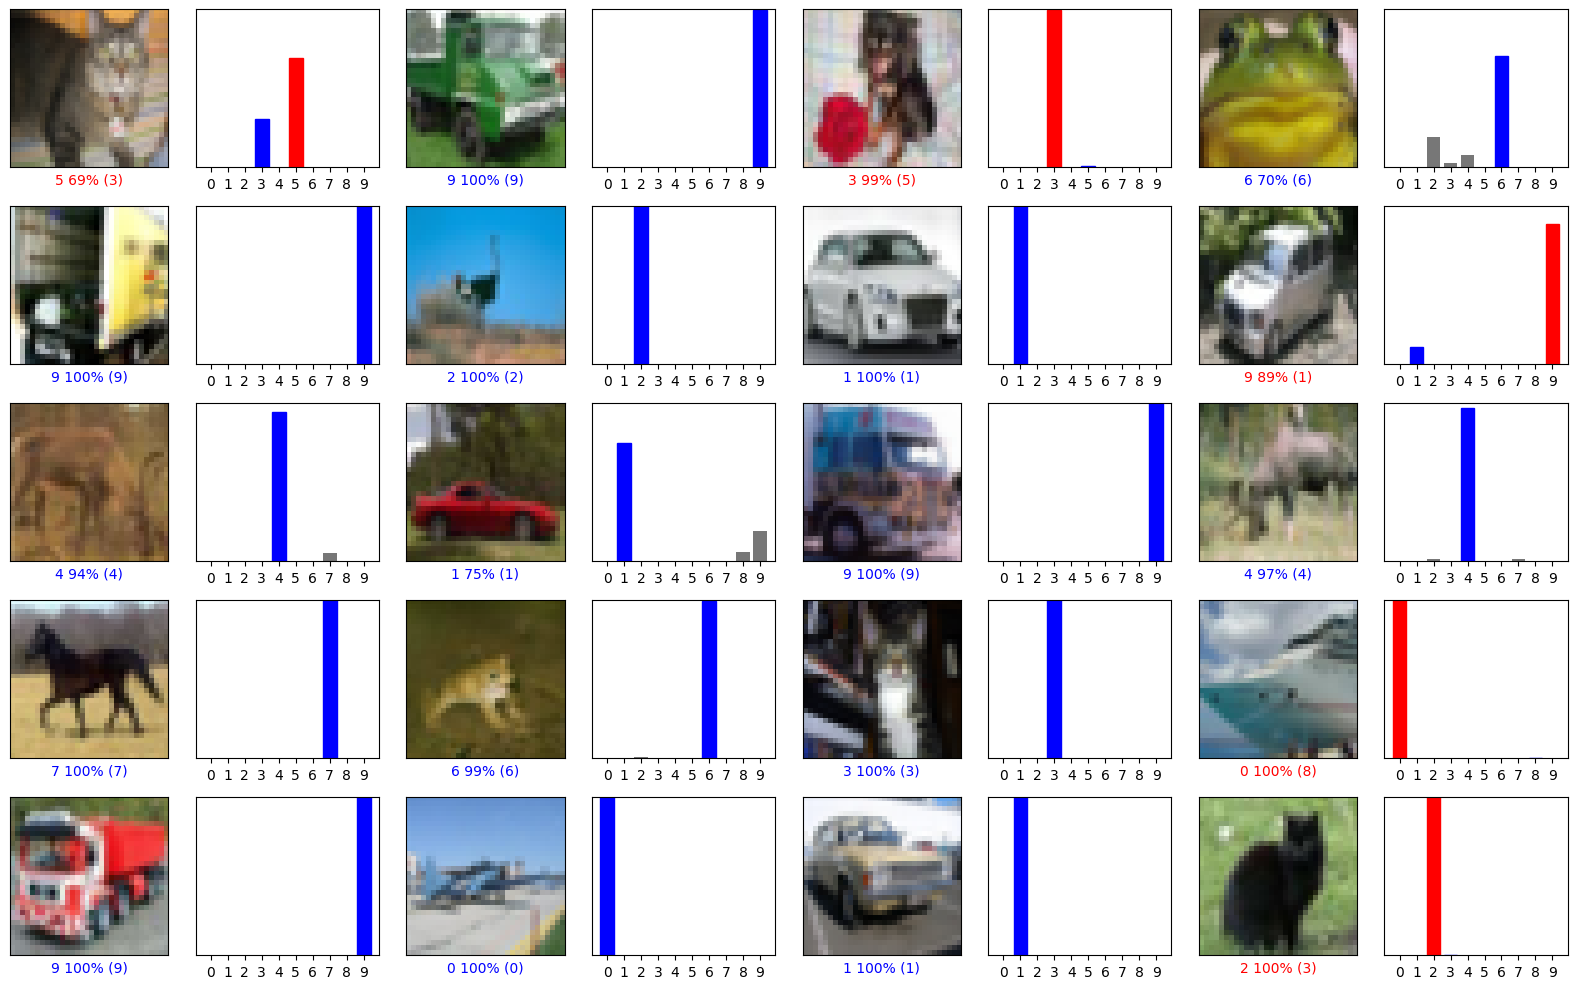

In [16]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

## 7. Guardamos el modelo para futuras evaluaciones

In [17]:
model_6.save(file_path +'cifar10_model_6.keras')

# Proyecto 7 - Cambio a Dropout

### Hipotesis:
Aplicando un poquito más de dropout para que el modelo pueda entrenar sin arriesgar mucho overfitting para mejorar el rendimiento.

## 2. Arquitectura de red del modelo - Proyecto 7


In [4]:
model_7 = ks.Sequential()
model_7.add(ks.layers.Input((32,32,3)))

# Lo que teníamos
model_7.add(ks.layers.Conv2D(32, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.MaxPooling2D((2, 2)))

# Nueva capa
model_7.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.Conv2D(64, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.MaxPooling2D((2, 2)))
model_7.add(ks.layers.Dropout(0.15)) 

# Otra capa encima de esa
model_7.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.Conv2D(128, (3, 3), strides=1, activation='relu', padding='same'))
model_7.add(ks.layers.MaxPooling2D((2, 2)))
model_7.add(ks.layers.Dropout(0.15)) 

model_7.add(ks.layers.Flatten())
model_7.add(ks.layers.Dense(128, activation='relu'))
model_7.add(ks.layers.Dropout(0.3))
model_7.add(ks.layers.Dense(10, activation='softmax'))


In [3]:
model_7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,322 (2.06 MB)

 Trainable params: 541,322 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizador, función error

In [5]:
model_7.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Preparamos los datos

In [5]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [6]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [7]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [49]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


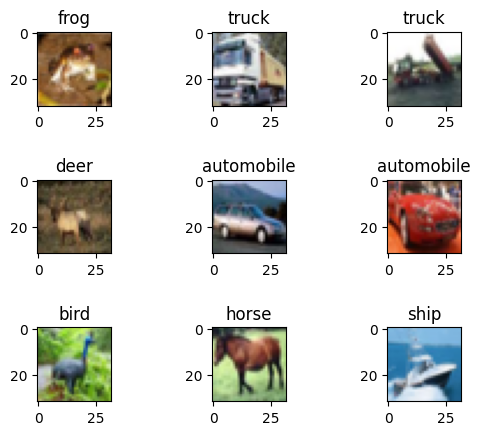

In [8]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [9]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [10]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [11]:
t = time.perf_counter()

history = model_7.fit(x_train_scaled, y_train, epochs=30,
                 batch_size= 512, validation_data=(x_val_scaled, y_val))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 264ms/step - accuracy: 0.2763 - loss: 1.9488 - val_accuracy: 0.3871 - val_loss: 1.6685
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - accuracy: 0.4314 - loss: 1.5526 - val_accuracy: 0.4766 - val_loss: 1.4435
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.5012 - loss: 1.3692 - val_accuracy: 0.5400 - val_loss: 1.2725
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.5541 - loss: 1.2468 - val_accuracy: 0.5890 - val_loss: 1.1480
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 257ms/step - accuracy: 0.5882 - loss: 1.1553 - val_accuracy: 0.6137 - val_loss: 1.0839
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.6235 - loss: 1.0630 - val_accuracy: 0.6539 - val_loss: 0.9909
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 317ms/step - accuracy: 0.6483 - loss: 0.9883 - val_accuracy: 0.6624 - val_loss: 0.9629
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 270ms/step - accuracy: 0.6734 - loss: 0.9307 - val_accu

In [12]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:11:40.556788


## 6. Evaluamos los resultados

In [13]:
_, acc = model_7.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 75.990


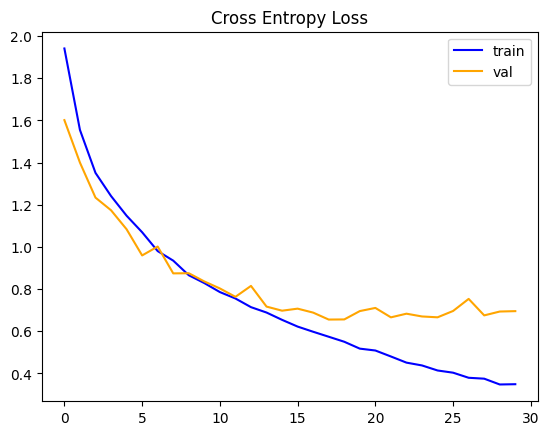

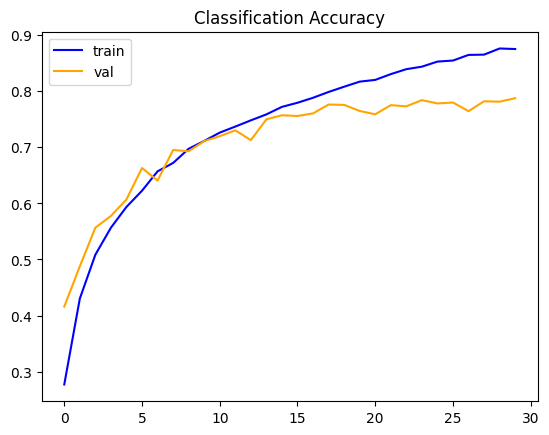

In [ ]:
plots.plot_cross_entropy_loss(history)
plots.plot_classification_accuracy(history)

In [14]:
predictions = model_7.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


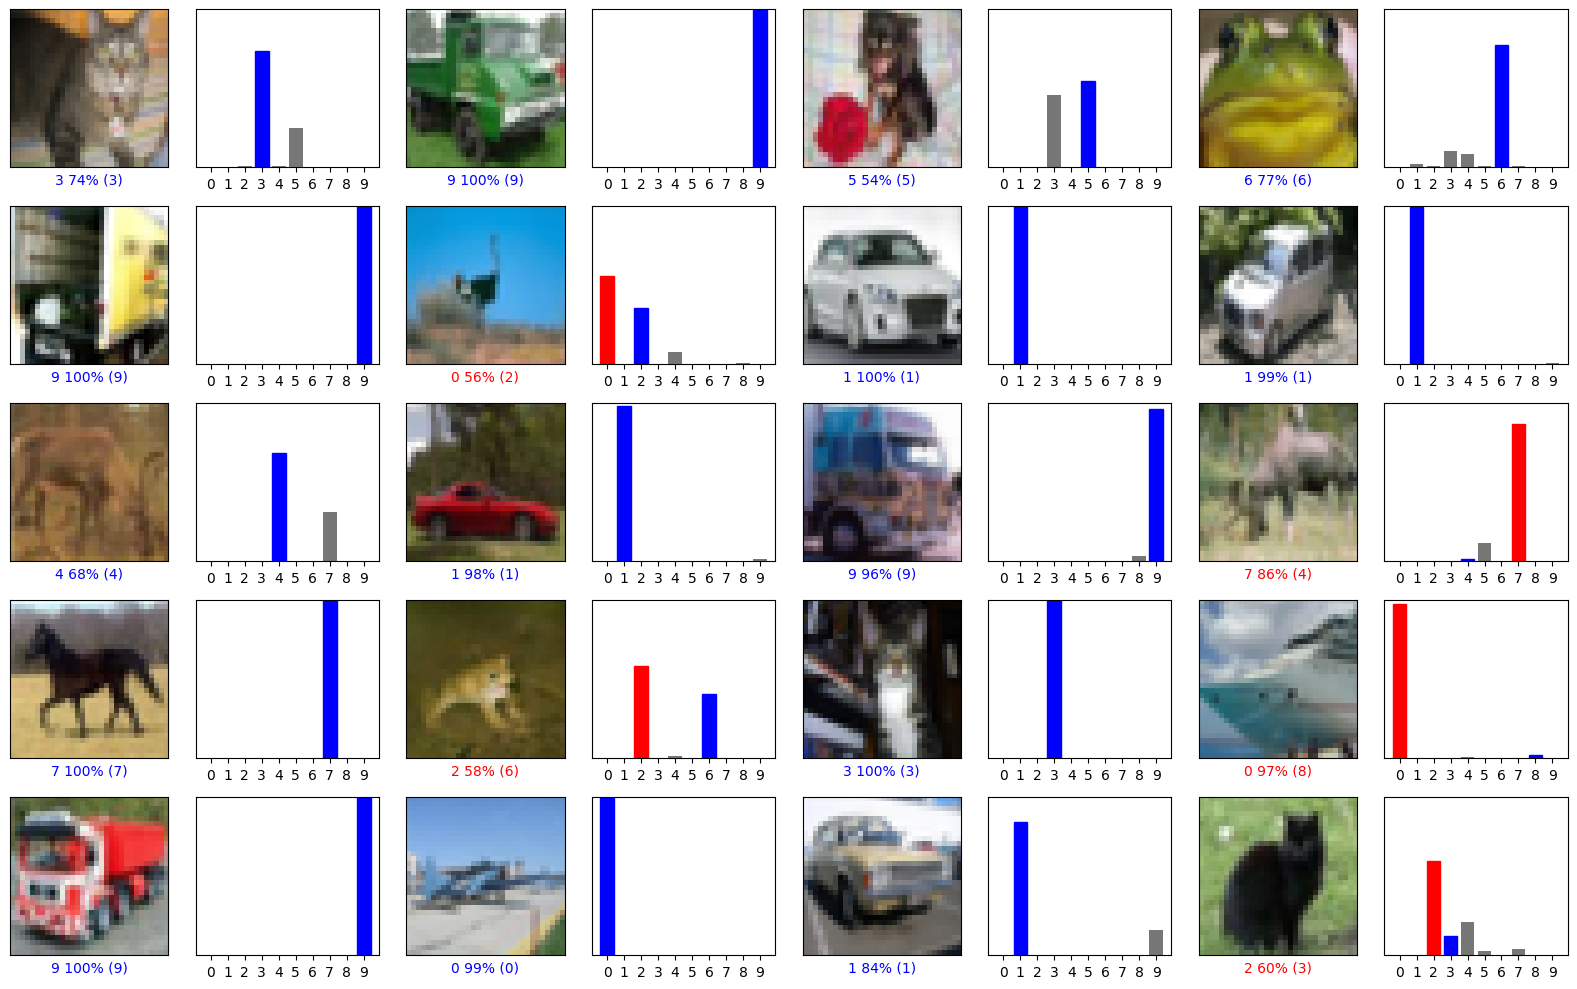

In [15]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

## 7. Guardamos el modelo para futuras evaluaciones

In [16]:
model_7.save(file_path +'cifar10_model_7.keras')

# Proyecto 8 - Con Data Augmentation

### Hipotesis:
Haciendo data augmentation con el modelo del proyecto 7 puede mejorarlo.

## 2. Arquitectura de red del modelo - Proyecto 8

### Cargando el modelo en vez de re-entrenar.


In [2]:
model_7_loaded = keras.models.load_model('models/final_cifar10_model_7.keras')

In [31]:
train_augment = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

## 3. Preparamos los datos

### Cargar dataset de nuevo

In [4]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [5]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


### Escalar datos

In [6]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [8]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


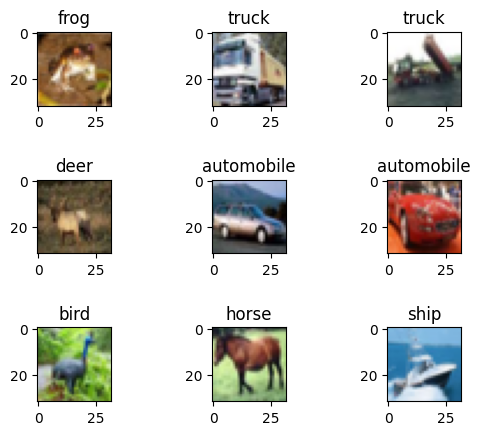

In [7]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [8]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [9]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 4. Entrenamiento

In [10]:
t = time.perf_counter()

history_da = model_7_loaded.fit(
    train_augment.flow(x_train_scaled, y_train, batch_size=32),
    validation_data=(x_val_scaled, y_val),
    epochs=30,
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.5970 - loss: 1.1527 - val_accuracy: 0.7086 - val_loss: 0.8574
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.6548 - loss: 0.9909 - val_accuracy: 0.7355 - val_loss: 0.7679
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.6787 - loss: 0.9293 - val_accuracy: 0.7316 - val_loss: 0.7681
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6895 - loss: 0.8974 - val_accuracy: 0.7183 - val_loss: 0.8371
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.7007 - loss: 0.8630 - val_accuracy: 0.7339 - val_loss: 0.7785
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.7085 - loss: 0.8426 - val_accuracy: 0.7526 - val_loss: 0.7140
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.7194 - loss: 0.8201 - val_accuracy: 0.7662 - val_loss: 0.6783
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.7235 -

## 5. Evaluamos los resultados

In [11]:
_, acc = model_7_loaded.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 77.520


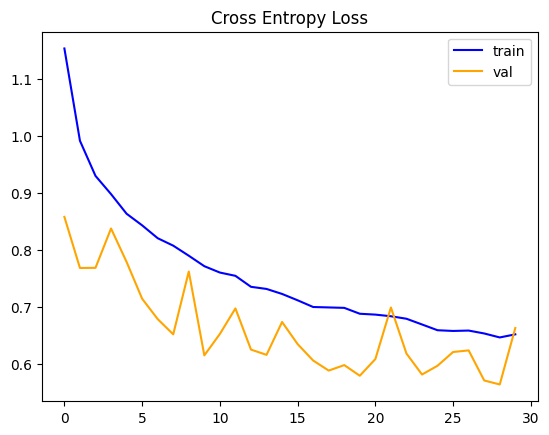

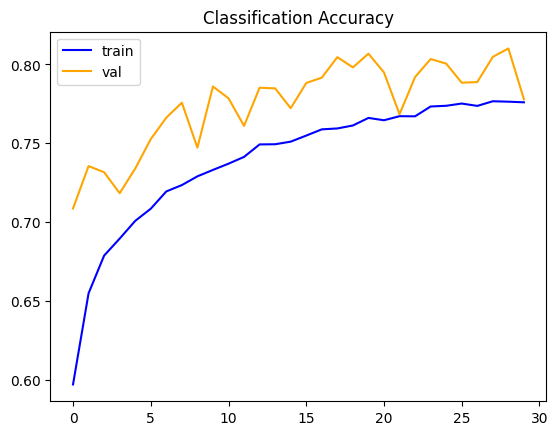

In [12]:
plots.plot_cross_entropy_loss(history_da)
plots.plot_classification_accuracy(history_da)

In [13]:
predictions = model_7_loaded.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


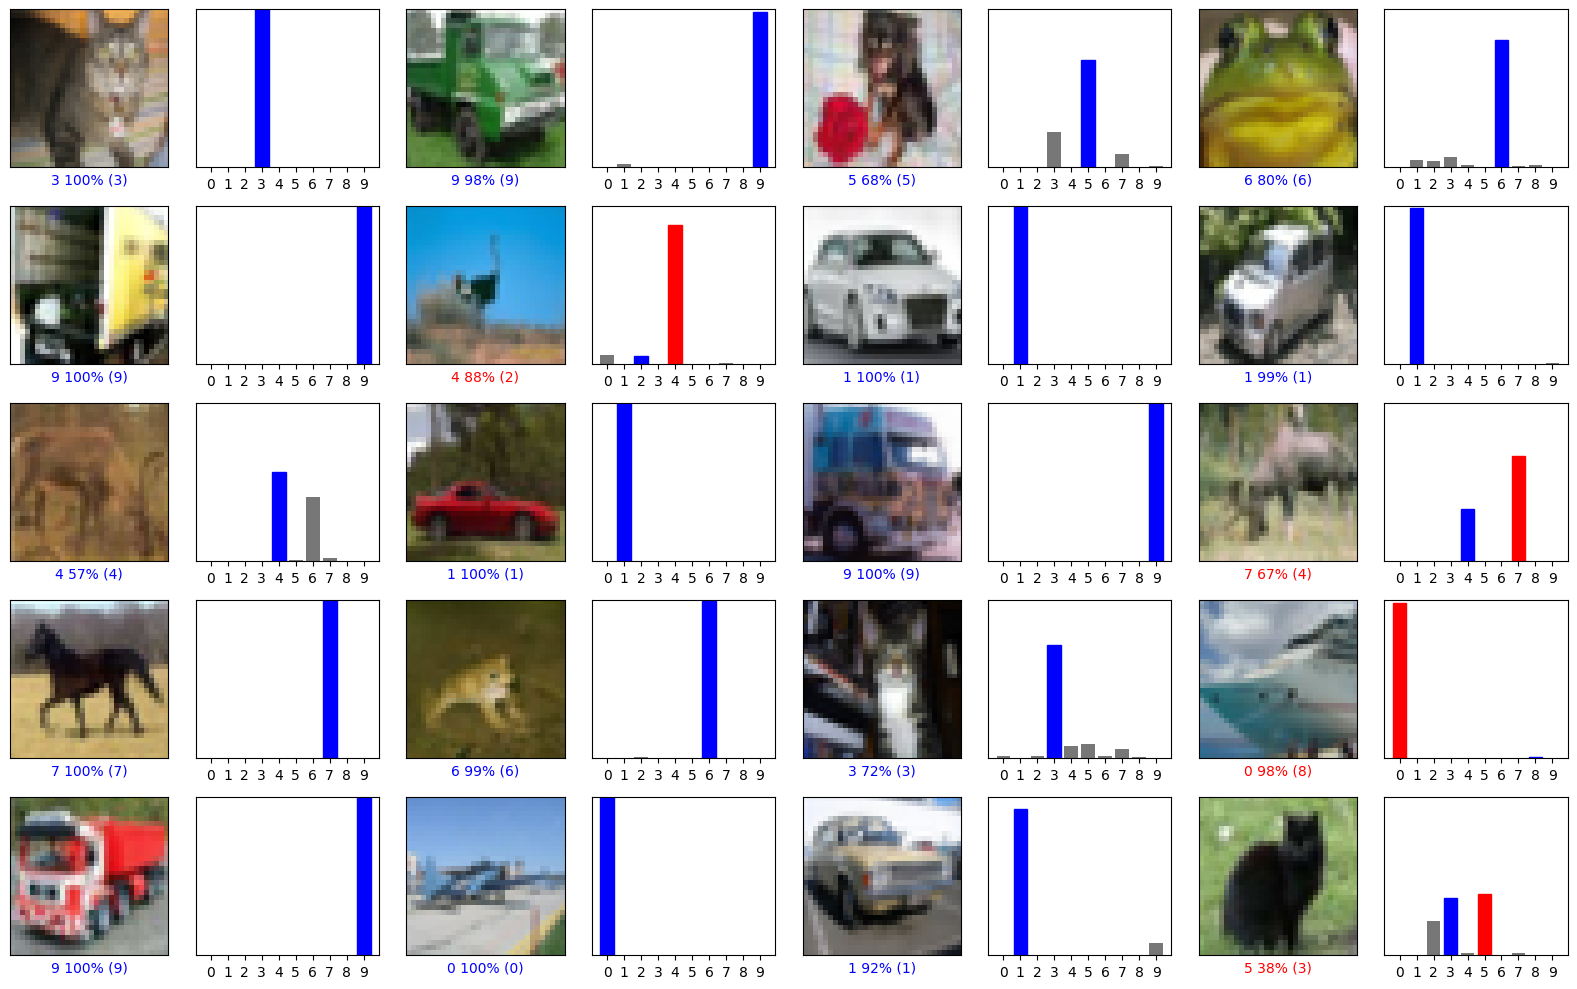

In [14]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

## 6. Guardamos el modelo para futuras evaluaciones

In [15]:
model_7_loaded.save(file_path + 'cifar10_model_8.keras')

# Proyecto 9 

### Hipotesis: 
Cambiar los parametros del fine tuning un poquito más para mejorar el rendimiento.

## 2. Cargar Modelo

In [2]:
model_7_loaded = keras.models.load_model('models/cifar10_model_7.keras')

In [4]:
train_augment_model_9 = ImageDataGenerator(
    rotation_range=20,      
    width_shift_range=0.15, 
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,        
    fill_mode='nearest'
)

## 3. Preparamos los datos

In [5]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [6]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [7]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [ ]:
print('Number of labels: %s' % len(cifar10_labels))

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


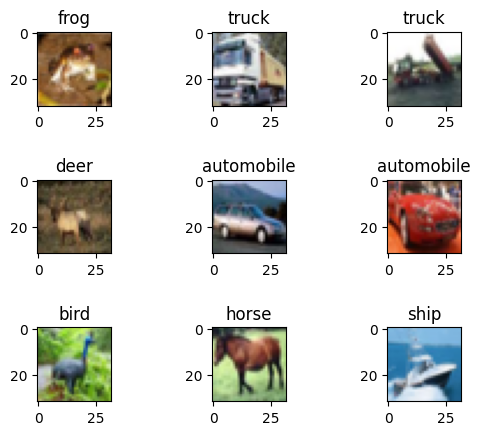

In [8]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [9]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [10]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 4. Entrenamiento

In [12]:
t = time.perf_counter()

history_da = model_7_loaded.fit(
    train_augment_model_9.flow(x_train_scaled, y_train, batch_size=32),
    validation_data=(x_val_scaled, y_val),
    epochs=30,
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.5529 - loss: 1.2775 - val_accuracy: 0.7200 - val_loss: 0.8087
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.6171 - loss: 1.1002 - val_accuracy: 0.6978 - val_loss: 0.8855
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6395 - loss: 1.0393 - val_accuracy: 0.7253 - val_loss: 0.7912
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.6542 - loss: 0.9993 - val_accuracy: 0.7256 - val_loss: 0.7991
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.6679 - loss: 0.9639 - val_accuracy: 0.7042 - val_loss: 0.8739
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.6761 - loss: 0.9378 - val_accuracy: 0.7493 - val_loss: 0.7317
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.6808 - loss: 0.9215 - val_accuracy: 0.7569 - val_loss: 0.7067
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.6859 -

In [13]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:16:27.672139


## 5. Evaluamos los resultados

In [14]:
_, acc = model_7_loaded.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 77.650


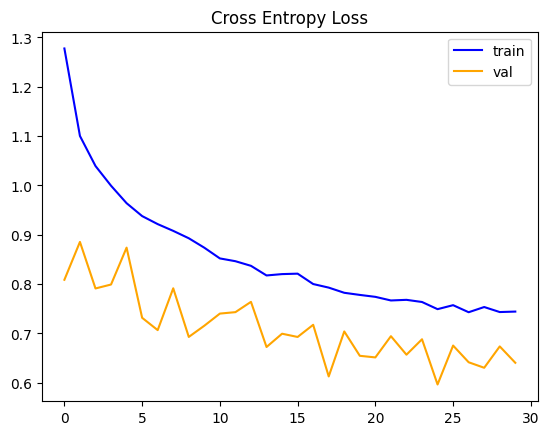

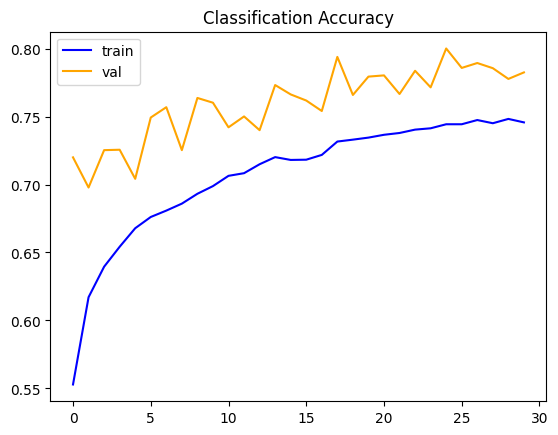

In [16]:
plots.plot_cross_entropy_loss(history_da)
plots.plot_classification_accuracy(history_da)

In [17]:
# predictions = model_7.predict(x_test_scaled)
predictions = model_7_loaded.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


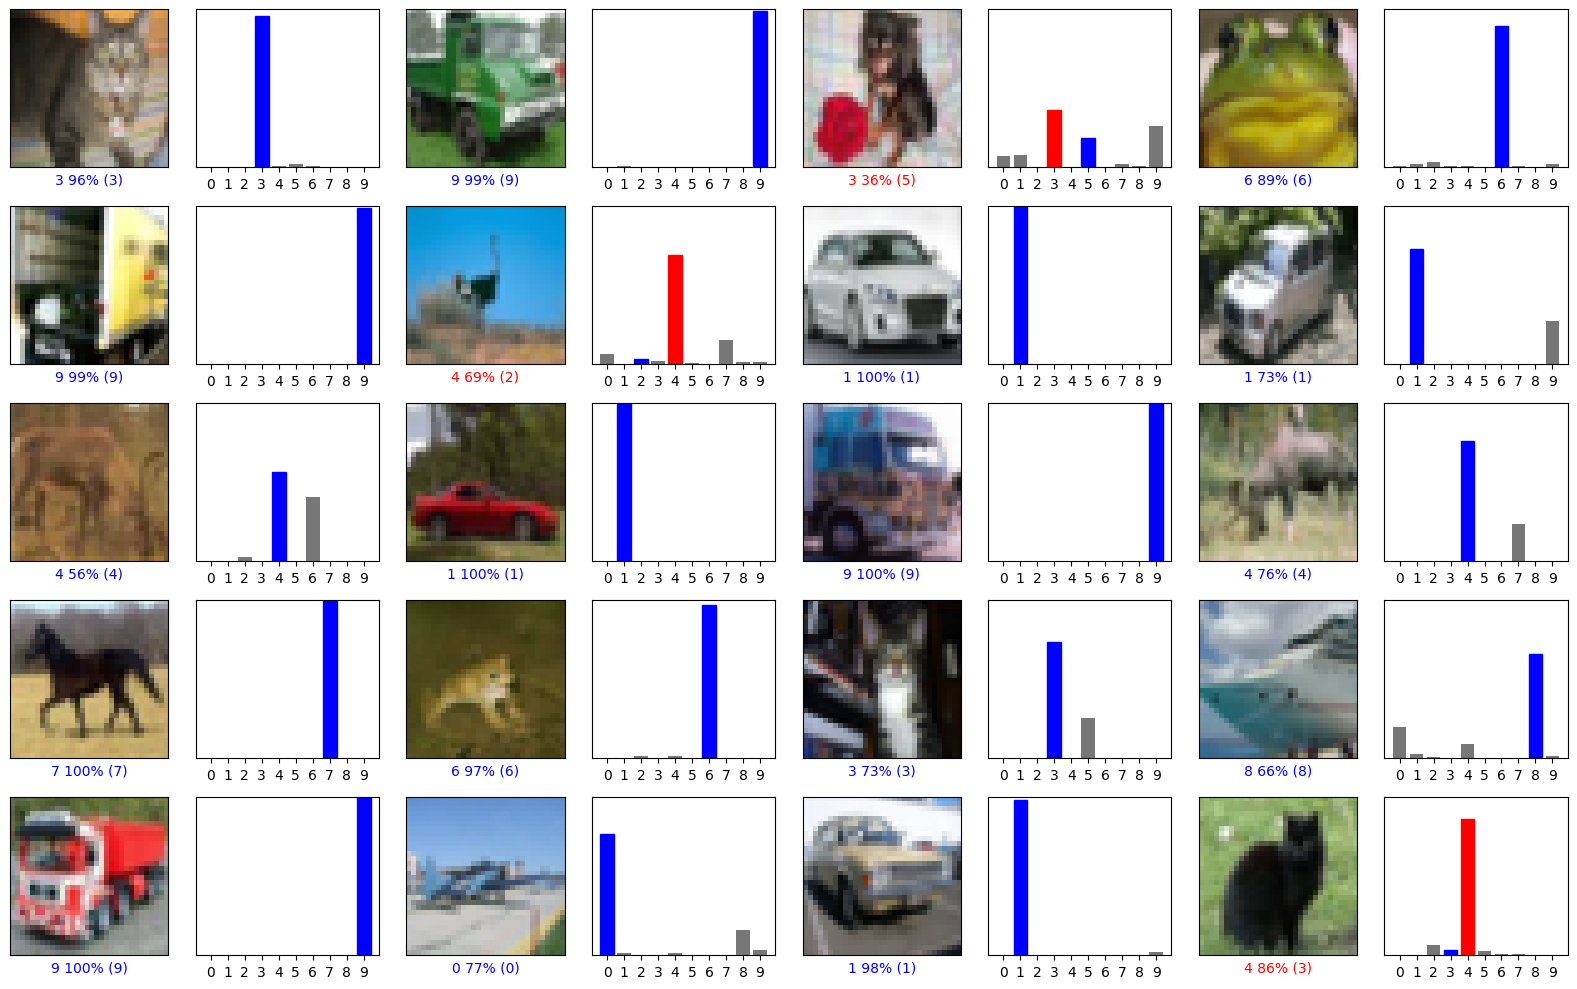

In [18]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

## 6. Guardamos el modelo para futuras evaluaciones

In [19]:
model_7_loaded.save(file_path +'cifar10_model_9.keras')

# Proyecto 10 - 
Modelo 7 + Data Augmentation + epochs comenzando desde ronda 30

### Hipotesis: 
Usar las mismas condiciones , pero con más epochs, comenzando donde estuvimos. Más tiempo para el modelo puede ayudar aumentar el acierto más allá del 80%. 

## 2. Arquitectura de red del modelo - Proyecto 10


In [ ]:
model_7_loaded = keras.models.load_model('models/final_cifar10_model_7.keras')

In [20]:
train_augment_model_10= ImageDataGenerator(
    rotation_range=20,      
    width_shift_range=0.15, 
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,        
    fill_mode='nearest'
)

In [21]:
x_train_rows, y_train, x_test_rows, y_test = utils.load_data(data_dir)

Validating split:
Train: X=(50000, 3072), y=(50000,)
Test: X=(10000, 3072), y=(10000,)


In [22]:
x_train_test = prepare.create_train_test(x_train_rows,x_test_rows)

x_train = x_train_test['x_train']
x_test = x_train_test['x_test']

prepare.validate_shape(x_train,y_train,'train')
prepare.validate_shape(x_test,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [23]:
scaled_values = prepare.scale_values(x_train, x_test)

x_train_scaled, x_test_scaled = scaled_values['x_train_scaled'],scaled_values['x_test_scaled'] 

prepare.validate_shape(x_train_scaled,y_train,'train')
prepare.validate_shape(x_test_scaled,y_test,'test')

Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


In [24]:
print('Number of labels: %s' % len(cifar10_labels))

Number of labels: 10


Train: X=(50000, 32, 32, 3), y=(50000,)
Test: X=(10000, 32, 32, 3), y=(10000,)


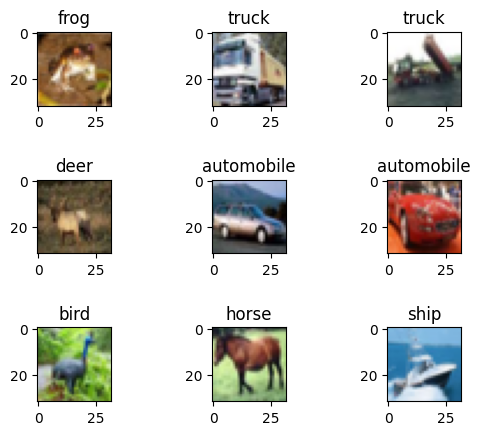

In [25]:
# Pintemos una muestra de las las imagenes del dataset MNIST

prepare.validate_shape(x_train, y_train,'train')
prepare.validate_shape(x_test, y_test,'test')

plots.cmap_samples(x_train,y_train,cifar10_labels)

In [26]:
validation_values = prepare.create_validation_training_data(x_train_scaled,y_train)

x_val_scaled, y_val, x_train_scaled, y_train = validation_values['x_val_scaled'],validation_values['y_val'],validation_values['x_train'],validation_values['y_train']

In [27]:
# Validamos el resultado

prepare.validate_shape(x_train_scaled, y_train,'train')
prepare.validate_shape(x_test_scaled, y_test,'test')
prepare.validate_shape(x_val_scaled, y_val,'validation')

Train: X=(40000, 32, 32, 3), y=(40000,)
Test: X=(10000, 32, 32, 3), y=(10000,)
Validation: X=(10000, 32, 32, 3), y=(10000,)


## 5. Entrenamiento

In [ ]:
t = time.perf_counter()

history_model_10 = model_7_loaded.fit(
    train_augment_model_10.flow(x_train_scaled, y_train, batch_size=32),
    validation_data=(x_val_scaled, y_val),
    epochs=50,  
    initial_epoch=30  
)

Epoch 31/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.7452 - loss: 0.7381 - val_accuracy: 0.7874 - val_loss: 0.6394
Epoch 32/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.7497 - loss: 0.7358 - val_accuracy: 0.7982 - val_loss: 0.5992
Epoch 33/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7518 - loss: 0.7319 - val_accuracy: 0.7946 - val_loss: 0.6275
Epoch 34/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7496 - loss: 0.7365 - val_accuracy: 0.8062 - val_loss: 0.5778
Epoch 35/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7509 - loss: 0.7321 - val_accuracy: 0.8029 - val_loss: 0.5895
Epoch 36/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.7521 - loss: 0.7295 - val_accuracy: 0.8025 - val_loss: 0.5959
Epoch 37/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7542 - loss: 0.7226 - val_accuracy: 0.8073 - val_loss: 0.5846
Epoch 38/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 

In [41]:
# Esto fue una alternativa, usando el training augmentation de un proyecto previo.

# t = time.perf_counter()

# history_model_10_b = model_7_loaded.fit(
#     train_augment.flow(x_train_scaled, y_train, batch_size=32),
#     validation_data=(x_val_scaled, y_val),
#     epochs=50,  
#     initial_epoch=30  
# )

# history_model_10 = model_7_loaded.fit(
#     train_augment_model_10.flow(x_train_scaled, y_train, batch_size=32),
#     validation_data=(x_val_scaled, y_val),
#     epochs=50,  
#     initial_epoch=30  
# )

In [33]:
elapsed_time = datetime.timedelta(seconds=(time.perf_counter() - t))

print('Tiempo de entrenamiento:', elapsed_time)

Tiempo de entrenamiento: 0:11:39.222996


## 6. Evaluamos los resultados

In [36]:
_, acc = model_7_loaded.evaluate(x_test_scaled, y_test, verbose=0)
print('> %.3f' % (acc * 100.0))

> 82.020


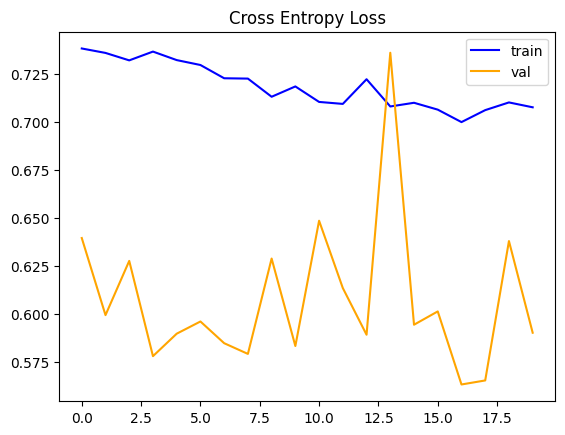

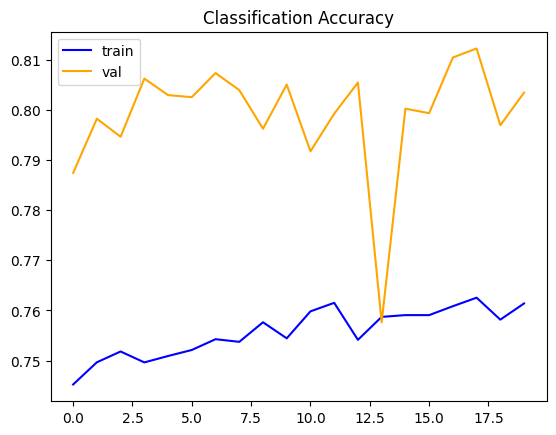

In [35]:
plots.plot_cross_entropy_loss(history_model_10)
plots.plot_classification_accuracy(history_model_10)

In [42]:
# plots.plot_cross_entropy_loss(history_model_10_b)
# plots.plot_classification_accuracy(history_model_10_b)

In [38]:
predictions = model_7_loaded.predict(x_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


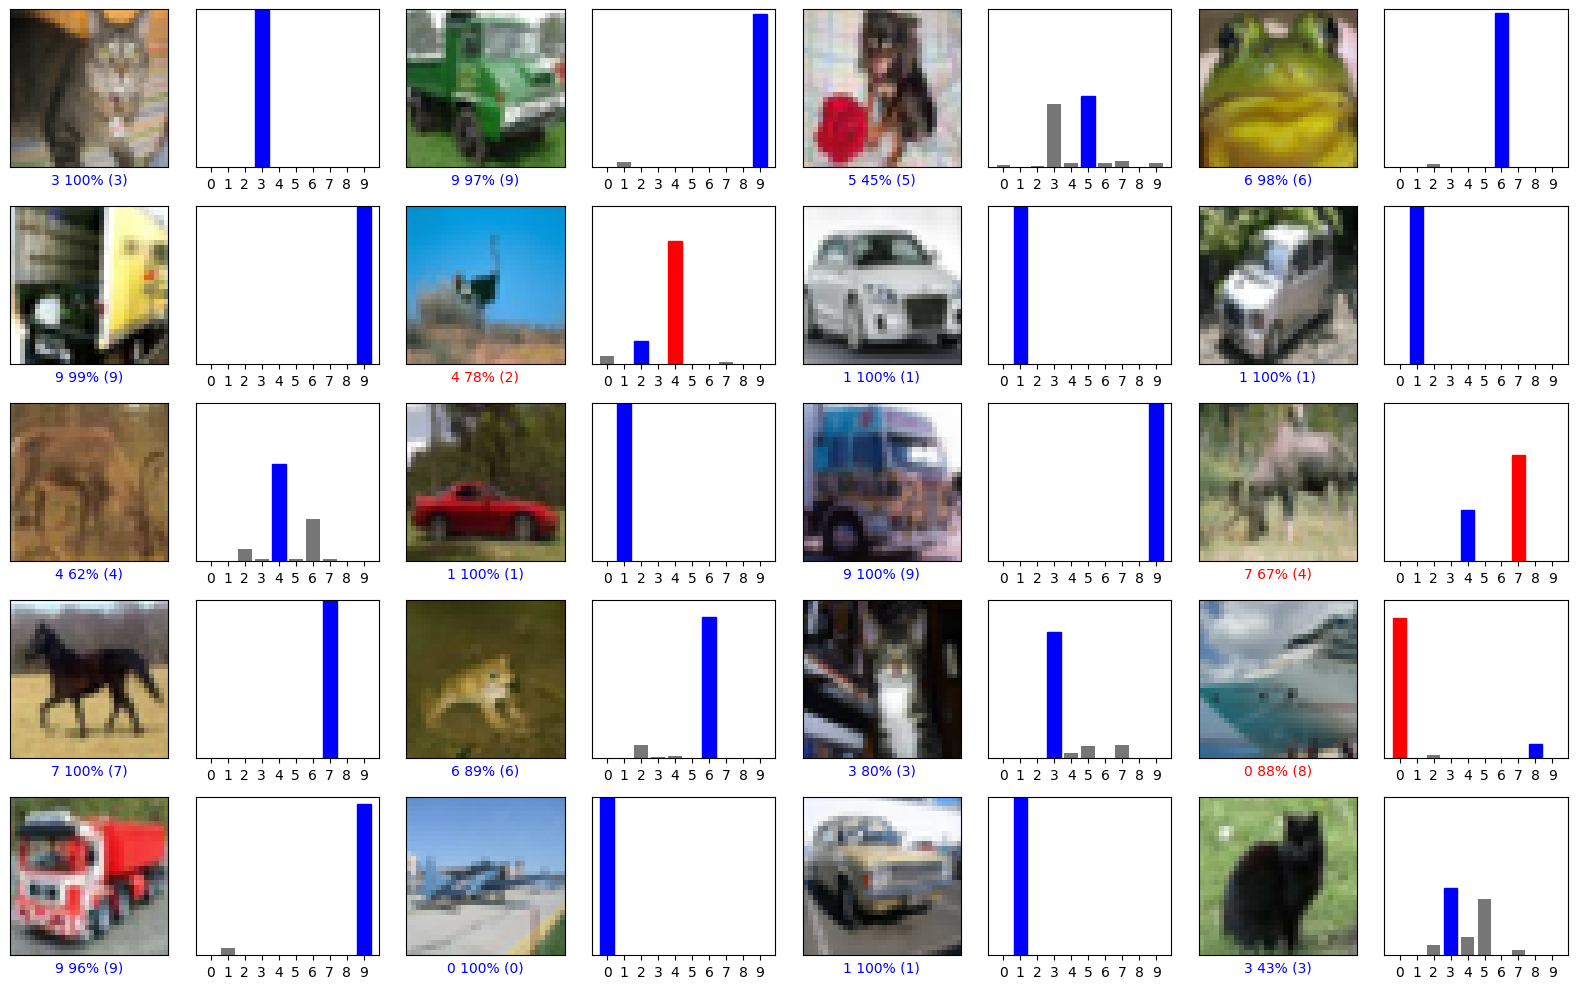

In [39]:
plots.show_test_results(x_test, y_test, cifar10_labels, predictions)

## 7. Guardamos el modelo para futuras evaluaciones

In [40]:
model_7_loaded.save(file_path +'cifar10_model_10.keras')